# BC-augmentation run

Training run `best_sweep_bcaugment` (config_best_sweep_bcaugment.yaml): trained on the 20-event
merged dataset (16 per-location magnitude/timing/desync/drain/combined perturbations + the existing
4 uniform q050-q150 events) 

`best.ckpt`/`best_csi.ckpt` reflect the best
val_loss/val_CSI_005 achieved across those ~560 epochs.

Question: does training on genuinely non-uniform, per-location BC perturbations fix the model's
failure to track physical volume share (leave-one-out sensitivity ladder in
`visualize_bc_nonuniform_sensitivity.ipynb`) and the zero-forcing draining failure mode, without
regressing on the standard held-out 1.0x event?

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Models to compare

In [2]:
CONFIG       = 'config_best_sweep.yaml'   # architecture auto-detected per checkpoint; evaluation dataset set below
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'   # the held-out 1.0x event

MODELS = [
    {'name': 'bcaugment_best_valloss',       'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5')},
    {'name': 'bcaugment_bestCSI',            'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment_bestCSI.h5')},
    {'name': 'multisim_msloss_best_valloss', 'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_multisim_multiscale_loss.h5')},  # pre-augmentation baseline
]

for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<32} exists={exists!s:<6} {size:>10}  {m['checkpoint']}")

bcaugment_best_valloss           exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_bcaugment.h5
bcaugment_bestCSI                exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_bcaugment_bestCSI.h5
multisim_msloss_best_valloss     exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multisim_multiscale_loss.h5


## Load shared config and dataset
Same test rollout is reused for every checkpoint, so the comparison is apples-to-apples.

In [3]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])


In [4]:
import os, pickle

train_pkl = os.path.join(REPO_ROOT, 'database', 'datasets', 'train', f'{DATASET_NAME}.pkl')
test_pkl  = os.path.join(REPO_ROOT, 'database', 'datasets', 'test',  f'{DATASET_NAME}.pkl')

print(f'train PKL exists: {os.path.exists(train_pkl)}  size: {os.path.getsize(train_pkl)/1e6:.1f} MB')
print(f'test  PKL exists: {os.path.exists(test_pkl)}   size: {os.path.getsize(test_pkl)/1e6:.1f} MB')

with open(train_pkl, 'rb') as f: train_data = pickle.load(f)
with open(test_pkl,  'rb') as f: test_data  = pickle.load(f)

print(f'\ntrain WD shape: {train_data[0].WD.shape}  max: {train_data[0].WD.max().item():.3f} m')
print(f'test  WD shape: {test_data[0].WD.shape}   max: {test_data[0].WD.max().item():.3f} m')
print(f'\nSame WD data: {torch.allclose(train_data[0].WD, test_data[0].WD)}')

train PKL exists: True  size: 70.9 MB
test  PKL exists: True   size: 70.9 MB

train WD shape: torch.Size([30079, 119])  max: 10.708 m
test  WD shape: torch.Size([30079, 119])   max: 10.708 m

Same WD data: True


## Load each checkpoint and run inference
Architecture (hid_features, K) is auto-detected from each checkpoint's state_dict.

In [5]:
def load_model_from_checkpoint(checkpoint_path):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features,
        num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': config['lr_info'],
        'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=device, **plmodule_kwargs
    )
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


results = {}
for m in MODELS:
    name, ckpt_path = m['name'], m['checkpoint']
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found at {ckpt_path}')
        continue
    print(f'Loading {name} ...')
    model, hid, K_list = load_model_from_checkpoint(ckpt_path)

    plot_rollout = PlotRollout(
        model, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters
    )

    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()

    csi_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
    csi_curve = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in csi_thresholds]

    csi_time_005 = plot_rollout._get_CSI(water_threshold=0.05).detach().cpu().numpy()
    csi_time_03  = plot_rollout._get_CSI(water_threshold=0.30).detach().cpu().numpy()
    if csi_time_005.ndim > 1:
        csi_time_005 = np.nanmean(csi_time_005, axis=0)
        csi_time_03  = np.nanmean(csi_time_03, axis=0)

    results[name] = {
        'hid_features': hid,
        'K': K_list,
        'rmse_wd': rmse_wd,
        'csi_005': csi_curve[csi_thresholds.index(0.05)],
        'csi_03':  csi_curve[csi_thresholds.index(0.30)],
        'csi_thresholds': csi_thresholds,
        'csi_curve': csi_curve,
        'csi_time_005': csi_time_005,
        'csi_time_03': csi_time_03,
        'plot_rollout': plot_rollout,
    }
    print(f'  hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={results[name]["csi_005"]:.4f}  CSI@0.30={results[name]["csi_03"]:.4f}')

Loading bcaugment_best_valloss ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1005  CSI@0.05=0.8527  CSI@0.30=0.8988
Loading bcaugment_bestCSI ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1387  CSI@0.05=0.8901  CSI@0.30=0.8660
Loading multisim_msloss_best_valloss ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1304  CSI@0.05=0.7991  CSI@0.30=0.8518


## Summary table

In [6]:
header = f"{'Model':<24} {'hid':>5} {'K':>22} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(f"{name:<24} {r['hid_features']:>5} {str(r['K']):>22} {r['rmse_wd']:>9.4f} {r['csi_005']:>9.4f} {r['csi_03']:>9.4f}")

Model                      hid                      K   RMSE_WD  CSI@0.05  CSI@0.30
-----------------------------------------------------------------------------------
bcaugment_best_valloss      32  [1, 1, 1, 5, 4, 3, 2]    0.1005    0.8527    0.8988
bcaugment_bestCSI           32  [1, 1, 1, 5, 4, 3, 2]    0.1387    0.8901    0.8660
multisim_msloss_best_valloss    32  [1, 1, 1, 5, 4, 3, 2]    0.1304    0.7991    0.8518


In [7]:
# --- Verdict vs the seed ruler (from seed_ruler_table.ipynb / results/seed_table.csv) ---
# The ruler is built from 5 single-sim seeds evaluated on their own training event
# (memorization regime). Every model here is evaluated on the held-out 1.0x event, which is
# NOT part of any of their training sets (bcaugment's merged pkl is 16 new sims + q050-150;
# multisim's is the 4 uniform-scaled events) — so landing inside or above the band is a
# meaningful generalization result for all three, not just the ones named "multisim".
import pandas as pd

seed_table = pd.read_csv('results/seed_table.csv')
ruler = seed_table[seed_table.ckpt == 'best_CSI']
RULER_LO, RULER_HI = ruler.CSI_005.min(), ruler.CSI_005.max()
print(f'best_CSI ruler (n={len(ruler)} seeds): CSI@0.05 mean={ruler.CSI_005.mean():.4f} '
      f'+- {ruler.CSI_005.std(ddof=1):.4f}   band [{RULER_LO:.4f}, {RULER_HI:.4f}]')
print()

header = f"{'Model':<28} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}  vs ruler band"
print(header)
print('-' * len(header))
for name, r in results.items():
    c = r['csi_005']
    verdict = 'ABOVE' if c > RULER_HI else ('BELOW' if c < RULER_LO else 'inside')
    print(f"{name:<28} {r['rmse_wd']:>9.4f} {c:>9.4f} {r['csi_03']:>9.4f}  {verdict}  (on an unseen event, held out from training)")

best_CSI ruler (n=5 seeds): CSI@0.05 mean=0.7609 +- 0.0419   band [0.7116, 0.8111]

Model                          RMSE_WD  CSI@0.05  CSI@0.30  vs ruler band
-------------------------------------------------------------------------
bcaugment_best_valloss          0.1005    0.8527    0.8988  ABOVE  (on an unseen event, held out from training)
bcaugment_bestCSI               0.1387    0.8901    0.8660  ABOVE  (on an unseen event, held out from training)
multisim_msloss_best_valloss    0.1304    0.7991    0.8518  inside  (on an unseen event, held out from training)


## Diagnostic — checkpoint epoch and per-scale volume sanity check

Before trusting a checkpoint, worth confirming which epoch it actually came from (a very early
epoch can mean a noisy val_CSI spike caught before the model actually converged — seen before in
other runs, e.g. wdleak bestCSI epoch 90) and whether the predicted/truth volume ratio is roughly
uniform across scales at the flood peak (a uniform deficit across all scales points to a global
under-/over-prediction rather than anything specific to non-uniform BC handling).

In [8]:
from utils.dataset import separate_multiscale_node_features

CHECK_MODELS = ['bcaugment_best_valloss', 'bcaugment_bestCSI', 'multisim_msloss_best_valloss']

print('--- checkpoint epochs ---')
epochs = {}
for name in CHECK_MODELS:
    m = next((m for m in MODELS if m['name'] == name), None)
    if m is None or not os.path.exists(m['checkpoint']):
        continue
    ck = torch.load(m['checkpoint'], map_location='cpu', weights_only=False)
    epochs[name] = ck.get('epoch', -1)
    print(f"{name:<28} epoch={epochs[name]}")

print('\n--- per-scale volume: prediction vs truth at the flood peak (1.0x event) ---')
node_ptr = test_dataset[0].node_ptr
num_scales = len(node_ptr) - 1
for name in CHECK_MODELS:
    if name not in results:
        continue
    r = results[name]
    pred_scales = separate_multiscale_node_features(r['plot_rollout'].predicted_rollout, node_ptr)
    real_scales = separate_multiscale_node_features(r['plot_rollout'].real_rollout, node_ptr)
    t_pk0 = int(real_scales[0][:, 0, :].clamp(min=0).sum(0).argmax())
    print(f'{name} (epoch {epochs.get(name, "?")}):')
    for s in range(num_scales):
        p_vol = pred_scales[s][:, 0, t_pk0].clamp(min=0).sum().item()
        g_vol = real_scales[s][:, 0, t_pk0].clamp(min=0).sum().item()
        ratio = p_vol / g_vol if g_vol else float('nan')
        print(f'  scale {s}: pred={p_vol:8.0f}  truth={g_vol:8.0f}  ratio={ratio:.3f}')

--- checkpoint epochs ---
bcaugment_best_valloss       epoch=243
bcaugment_bestCSI            epoch=280
multisim_msloss_best_valloss epoch=813

--- per-scale volume: prediction vs truth at the flood peak (1.0x event) ---
bcaugment_best_valloss (epoch 243):
  scale 0: pred=    8208  truth=    7767  ratio=1.057
  scale 1: pred=    1139  truth=    1132  ratio=1.006
  scale 2: pred=     356  truth=     342  ratio=1.040
  scale 3: pred=     102  truth=     102  ratio=1.006
bcaugment_bestCSI (epoch 280):
  scale 0: pred=    5056  truth=    7767  ratio=0.651
  scale 1: pred=     715  truth=    1132  ratio=0.632
  scale 2: pred=     229  truth=     342  ratio=0.670
  scale 3: pred=      71  truth=     102  ratio=0.696
multisim_msloss_best_valloss (epoch 813):
  scale 0: pred=    7808  truth=    7767  ratio=1.005
  scale 1: pred=    1095  truth=    1132  ratio=0.967
  scale 2: pred=     346  truth=     342  ratio=1.010
  scale 3: pred=      93  truth=     102  ratio=0.911


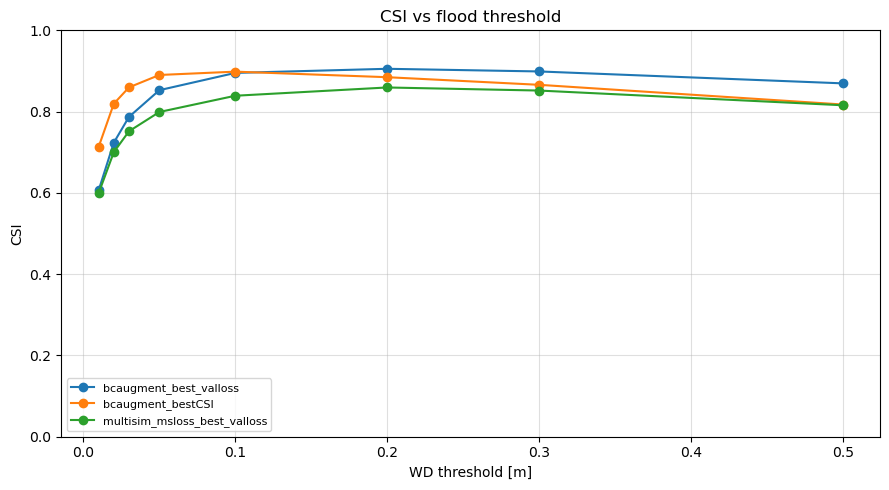

In [9]:
# CSI vs threshold — all models
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.plot(r['csi_thresholds'], r['csi_curve'], 'o-', label=name)
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

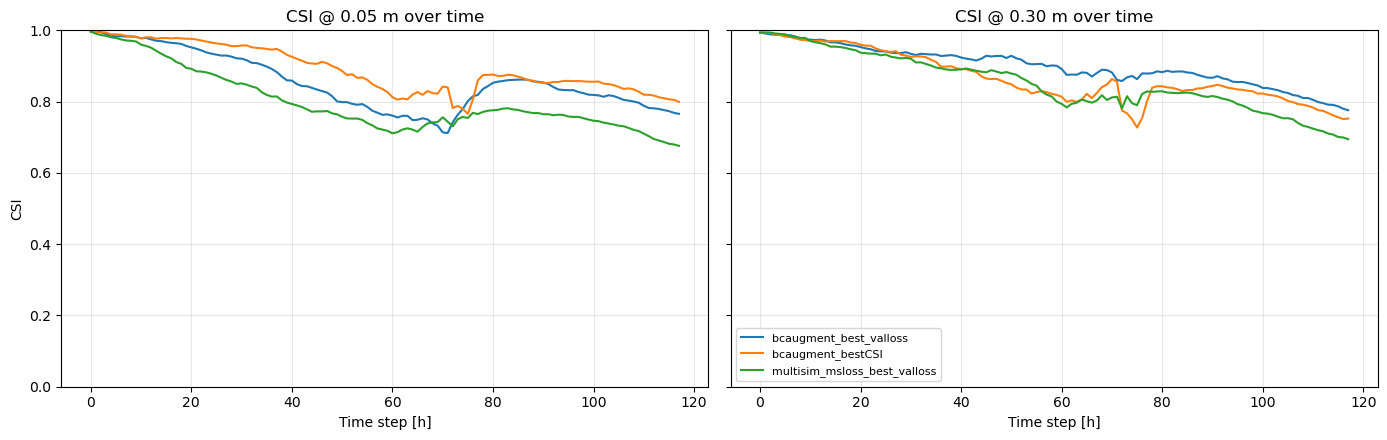

In [10]:
# CSI over time — all models
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, r in results.items():
    axes[0].plot(r['csi_time_005'], label=name)
    axes[1].plot(r['csi_time_03'], label=name)
axes[0].set_title('CSI @ 0.05 m over time')
axes[1].set_title('CSI @ 0.30 m over time')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

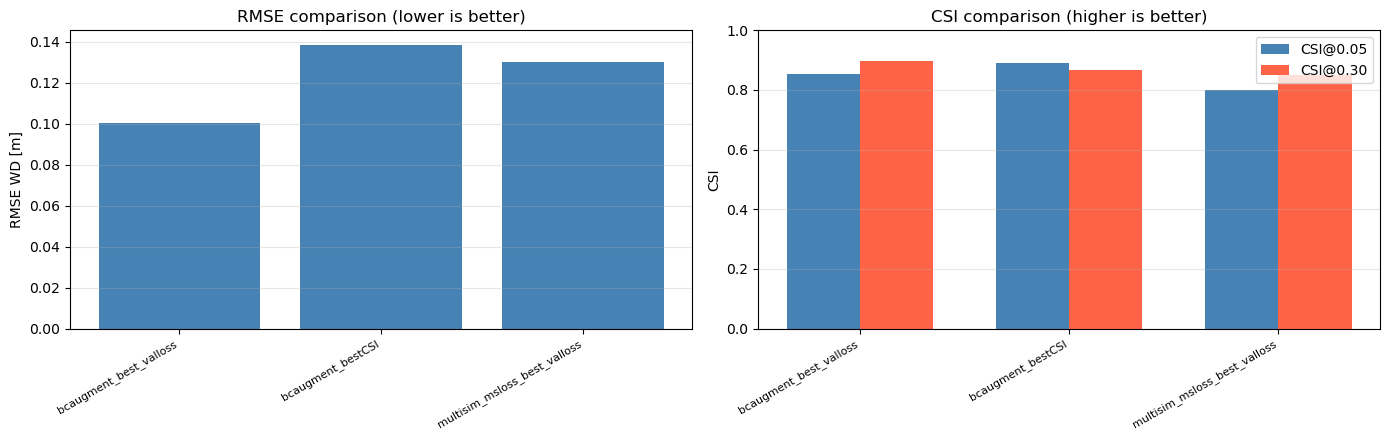

In [11]:
# RMSE / CSI bar comparison
names = list(results.keys())
rmse_vals = [results[n]['rmse_wd'] for n in names]
csi005_vals = [results[n]['csi_005'] for n in names]
csi03_vals = [results[n]['csi_03'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(names))

axes[0].bar(x, rmse_vals, color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE WD [m]')
axes[0].set_title('RMSE comparison (lower is better)')
axes[0].grid(True, alpha=0.3, axis='y')

width = 0.35
axes[1].bar(x - width/2, csi005_vals, width, label='CSI@0.05', color='steelblue')
axes[1].bar(x + width/2, csi03_vals, width, label='CSI@0.30', color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('CSI')
axes[1].set_ylim(0, 1)
axes[1].set_title('CSI comparison (higher is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step-0 diagnostics — FP/FN decomposition @ 0.05 m
Same diagnostics as `compare_weighted_rmse_runs.ipynb`: failure-mode identification before touching anything.
Timesteps for the spatial maps are picked automatically from the real wet-area curve
(rising limb = half-rise, peak = max wet area, recession = half-fall).

Diagnostic timesteps (of 118): {'rising limb': 71, 'peak': 76, 'recession': 117}


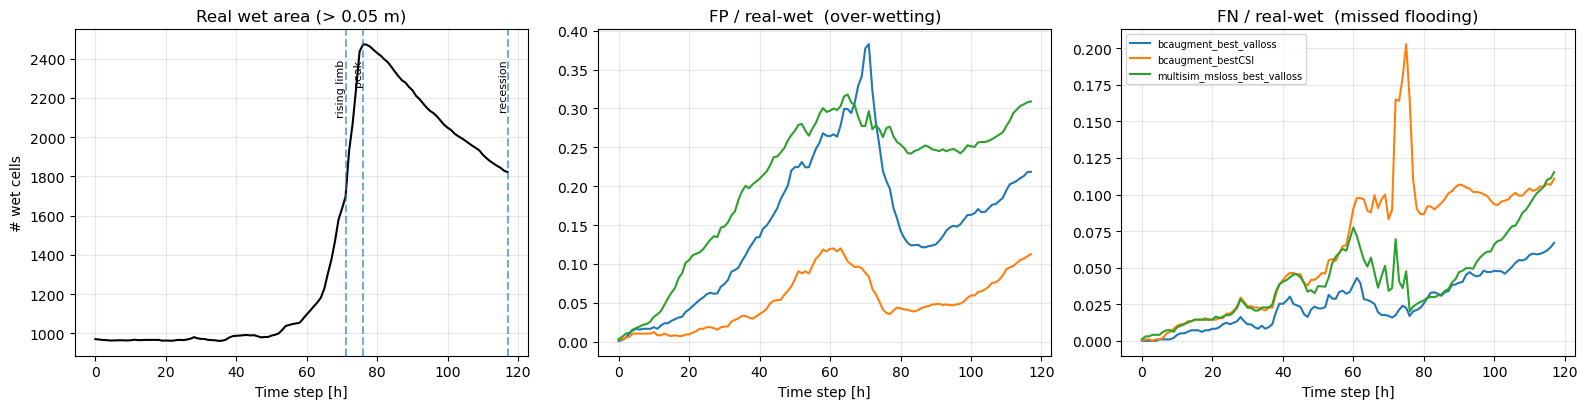

Model                     mean FP/wet  mean FN/wet  dominant error
bcaugment_best_valloss          0.150        0.026  FP (over-wetting)
bcaugment_bestCSI               0.052        0.065  FN (under-prediction)
multisim_msloss_best_valloss        0.209        0.042  FP (over-wetting)


In [12]:
from utils.miscellaneous import get_rollout_confusion_matrix

THR = 0.05  # m — WD_scaler is None, so rollouts are already in physical units

# Real wet area over time (identical for all models) — used to locate the flood phases
real_s0 = next(iter(results.values()))['plot_rollout']._real_rollout_s0  # [nodes, vars, time]
wet_area = (real_s0[:, 0, :] > THR).sum(0).cpu().numpy()

t_peak = int(wet_area.argmax())
base = wet_area[0]
half = base + 0.5 * (wet_area.max() - base)
rise_c = np.where(wet_area[:t_peak] <= half)[0]
t_rise = int(rise_c[-1]) if len(rise_c) else max(t_peak // 2, 1)
rec_c = np.where(wet_area[t_peak:] <= half)[0]
t_rec = int(t_peak + rec_c[0]) if len(rec_c) else int(wet_area.shape[0] - 1)
phases = {'rising limb': t_rise, 'peak': t_peak, 'recession': t_rec}
print(f'Diagnostic timesteps (of {wet_area.shape[0]}):', phases)

conf = {}
for name, r in results.items():
    TP, TN, FP, FN = get_rollout_confusion_matrix(
        r['plot_rollout']._predicted_rollout_s0, r['plot_rollout']._real_rollout_s0,
        water_threshold=THR)
    conf[name] = dict(zip(['TP', 'TN', 'FP', 'FN'],
                          [v.cpu().numpy().astype(float) for v in (TP, TN, FP, FN)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(wet_area, 'k-')
for ph, t in phases.items():
    axes[0].axvline(t, ls='--', alpha=0.6)
    axes[0].annotate(ph, (t, wet_area.max() * 0.97), rotation=90, fontsize=8, ha='right', va='top')
axes[0].set_title(f'Real wet area (> {THR} m)')
axes[0].set_ylabel('# wet cells')

for name, c in conf.items():
    wet = c['TP'] + c['FN']  # real wet cells per timestep
    axes[1].plot(c['FP'] / wet, label=name)
    axes[2].plot(c['FN'] / wet, label=name)
axes[1].set_title('FP / real-wet  (over-wetting)')
axes[2].set_title('FN / real-wet  (missed flooding)')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.grid(alpha=0.3)
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"{'Model':<24} {'mean FP/wet':>12} {'mean FN/wet':>12}  dominant error")
for name, c in conf.items():
    wet = c['TP'] + c['FN']
    fp, fn = np.nanmean(c['FP'] / wet), np.nanmean(c['FN'] / wet)
    dom = 'FP (over-wetting)' if fp > fn else 'FN (under-prediction)'
    print(f"{name:<24} {fp:>12.3f} {fn:>12.3f}  {dom}")

### Spatial TP / FP / FN maps at rising limb, peak, recession
Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).
A thin FP/FN ring around the flood extent = fringe problem; FN patches in whole side valleys = front timing / drift.

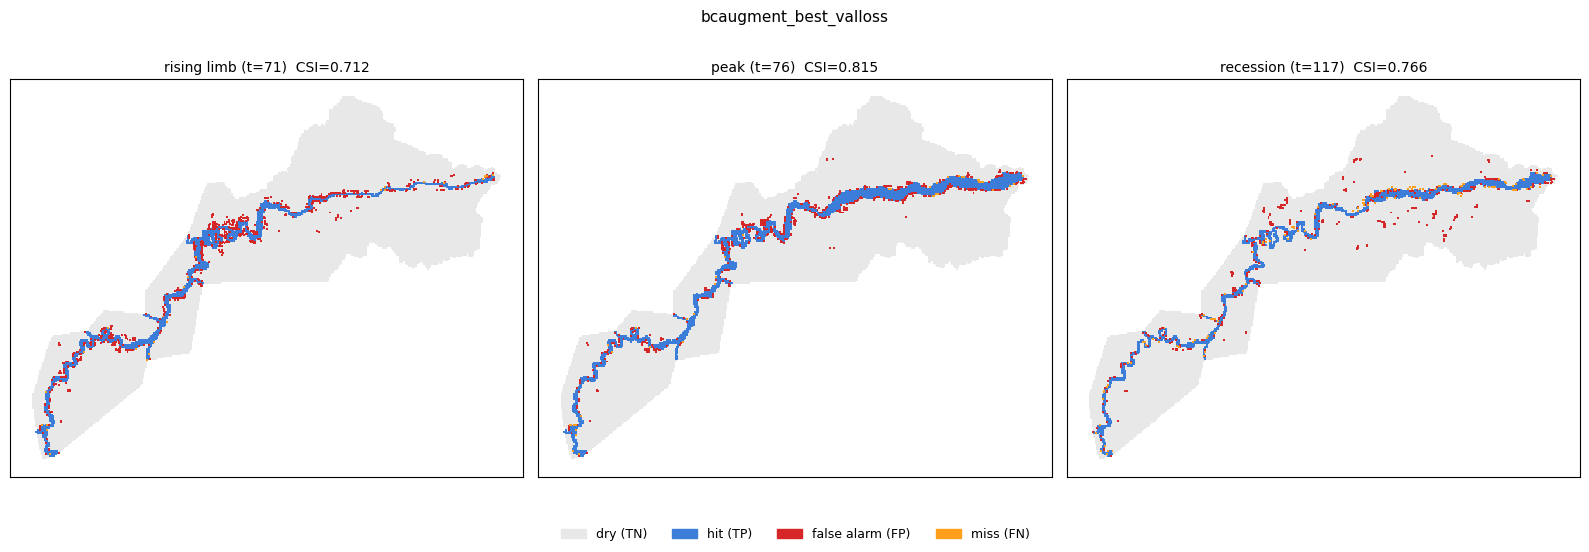

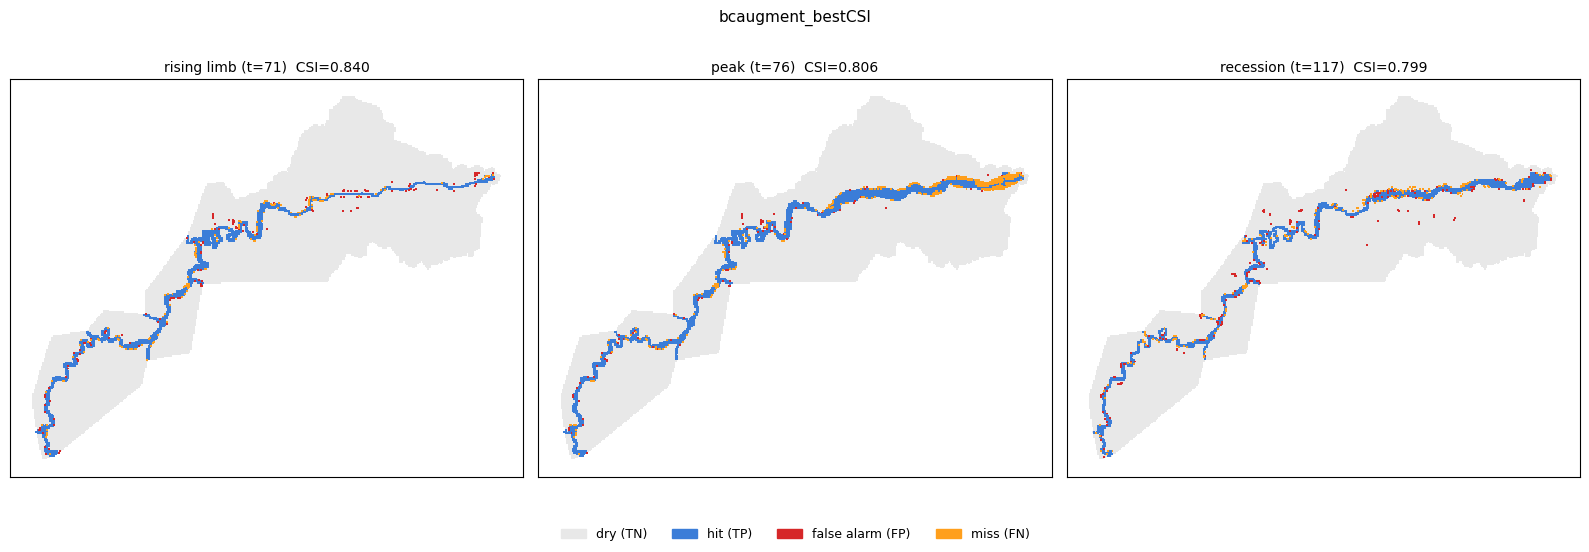

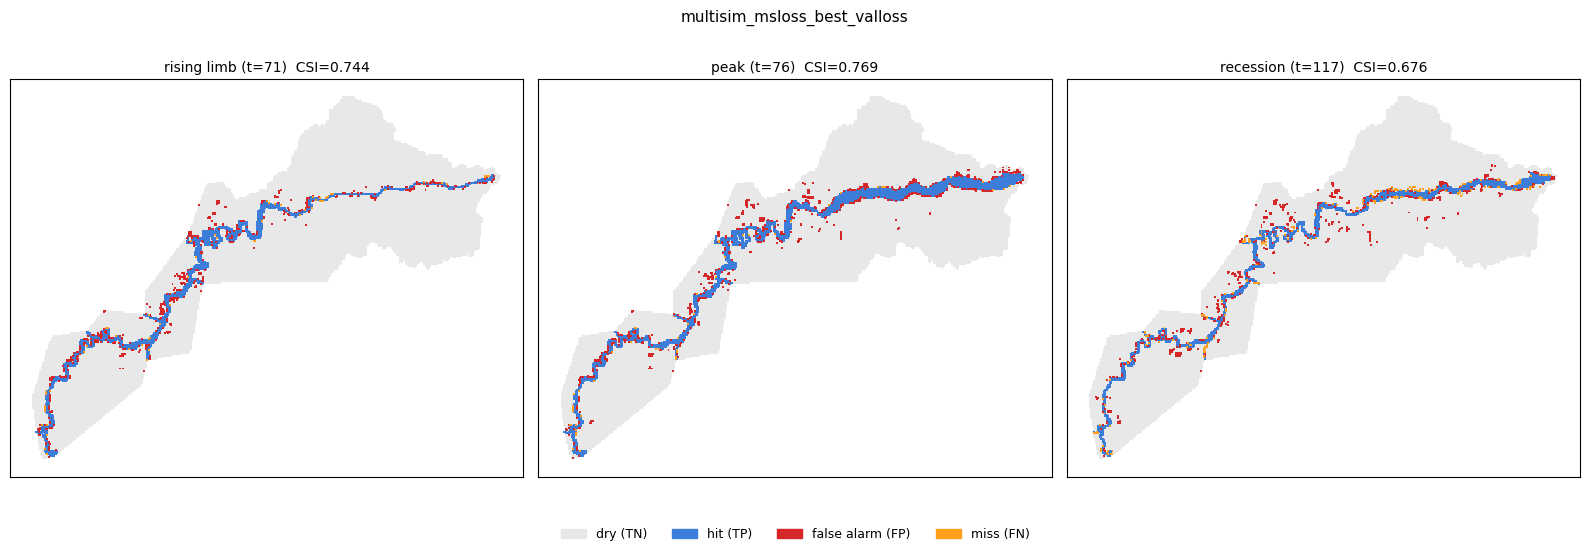

In [13]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n_s0 = real_s0.shape[0]
pos_s0 = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0]  # scale-0 nodes come first in the multiscale stack

cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

for name, r in results.items():
    pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
    real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
    fig, axes = plt.subplots(1, len(phases), figsize=(16, 5.5))
    for ax, (ph, t) in zip(axes, phases.items()):
        p, g = pred[:, t] > THR, real[:, t] > THR
        cat = np.zeros(n_s0, dtype=int)
        cat[p & g] = 1
        cat[p & ~g] = 2
        cat[~p & g] = 3
        order = np.argsort(cat, kind='stable')  # draw FP/FN on top of TP/TN
        ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
                   vmin=0, vmax=3, s=2, marker='s', linewidths=0)
        csi_t = (p & g).sum() / max((p | g).sum(), 1)
        ax.set_title(f'{ph} (t={t})  CSI={csi_t:.3f}', fontsize=10)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(name, fontsize=11)
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

--- bcaugment_best_valloss ---


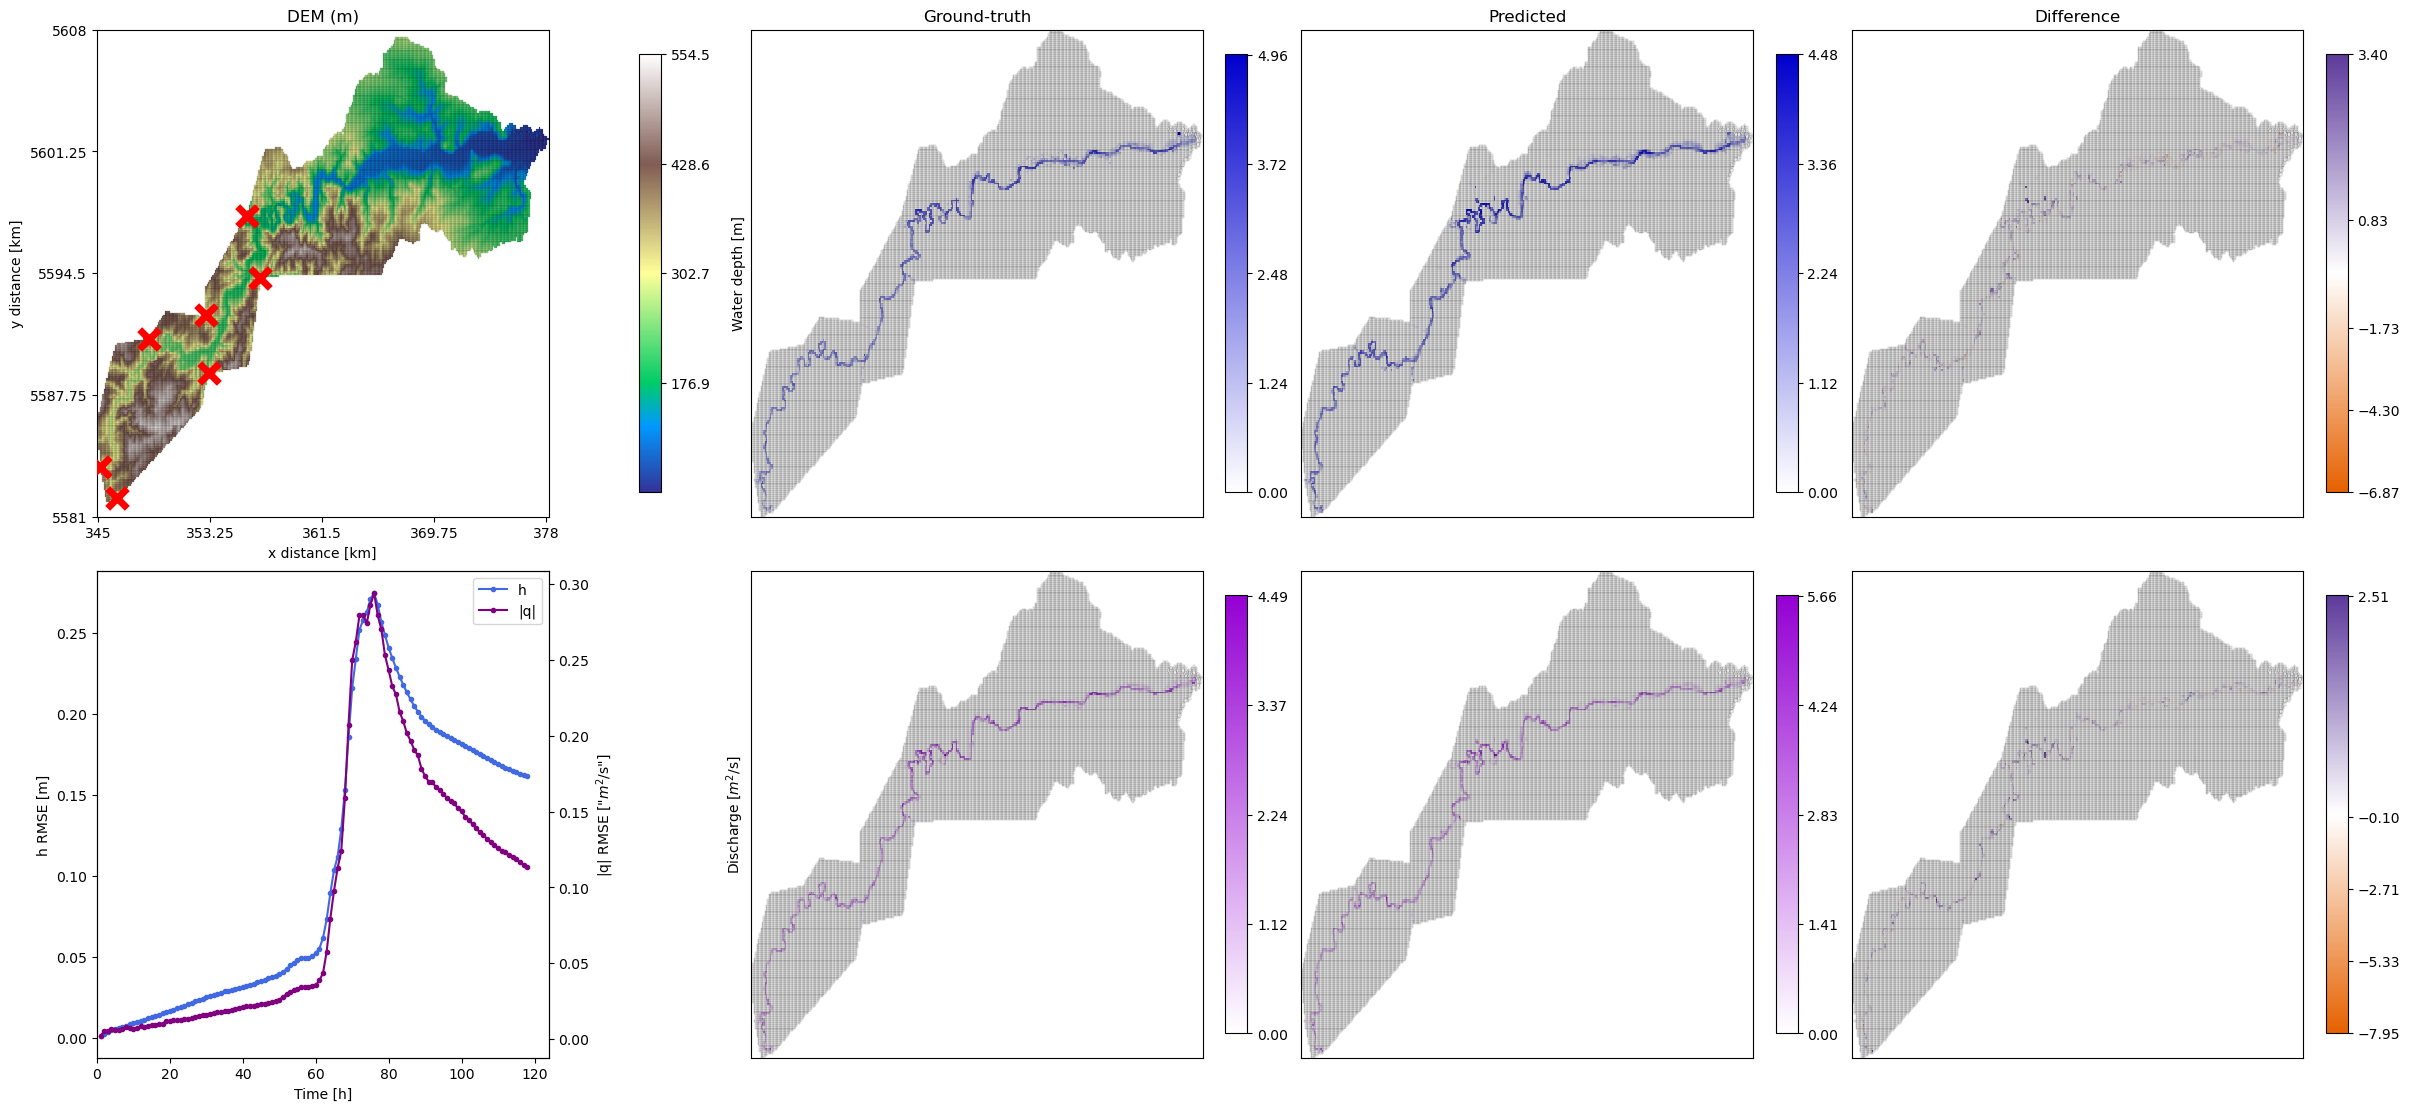

--- bcaugment_bestCSI ---


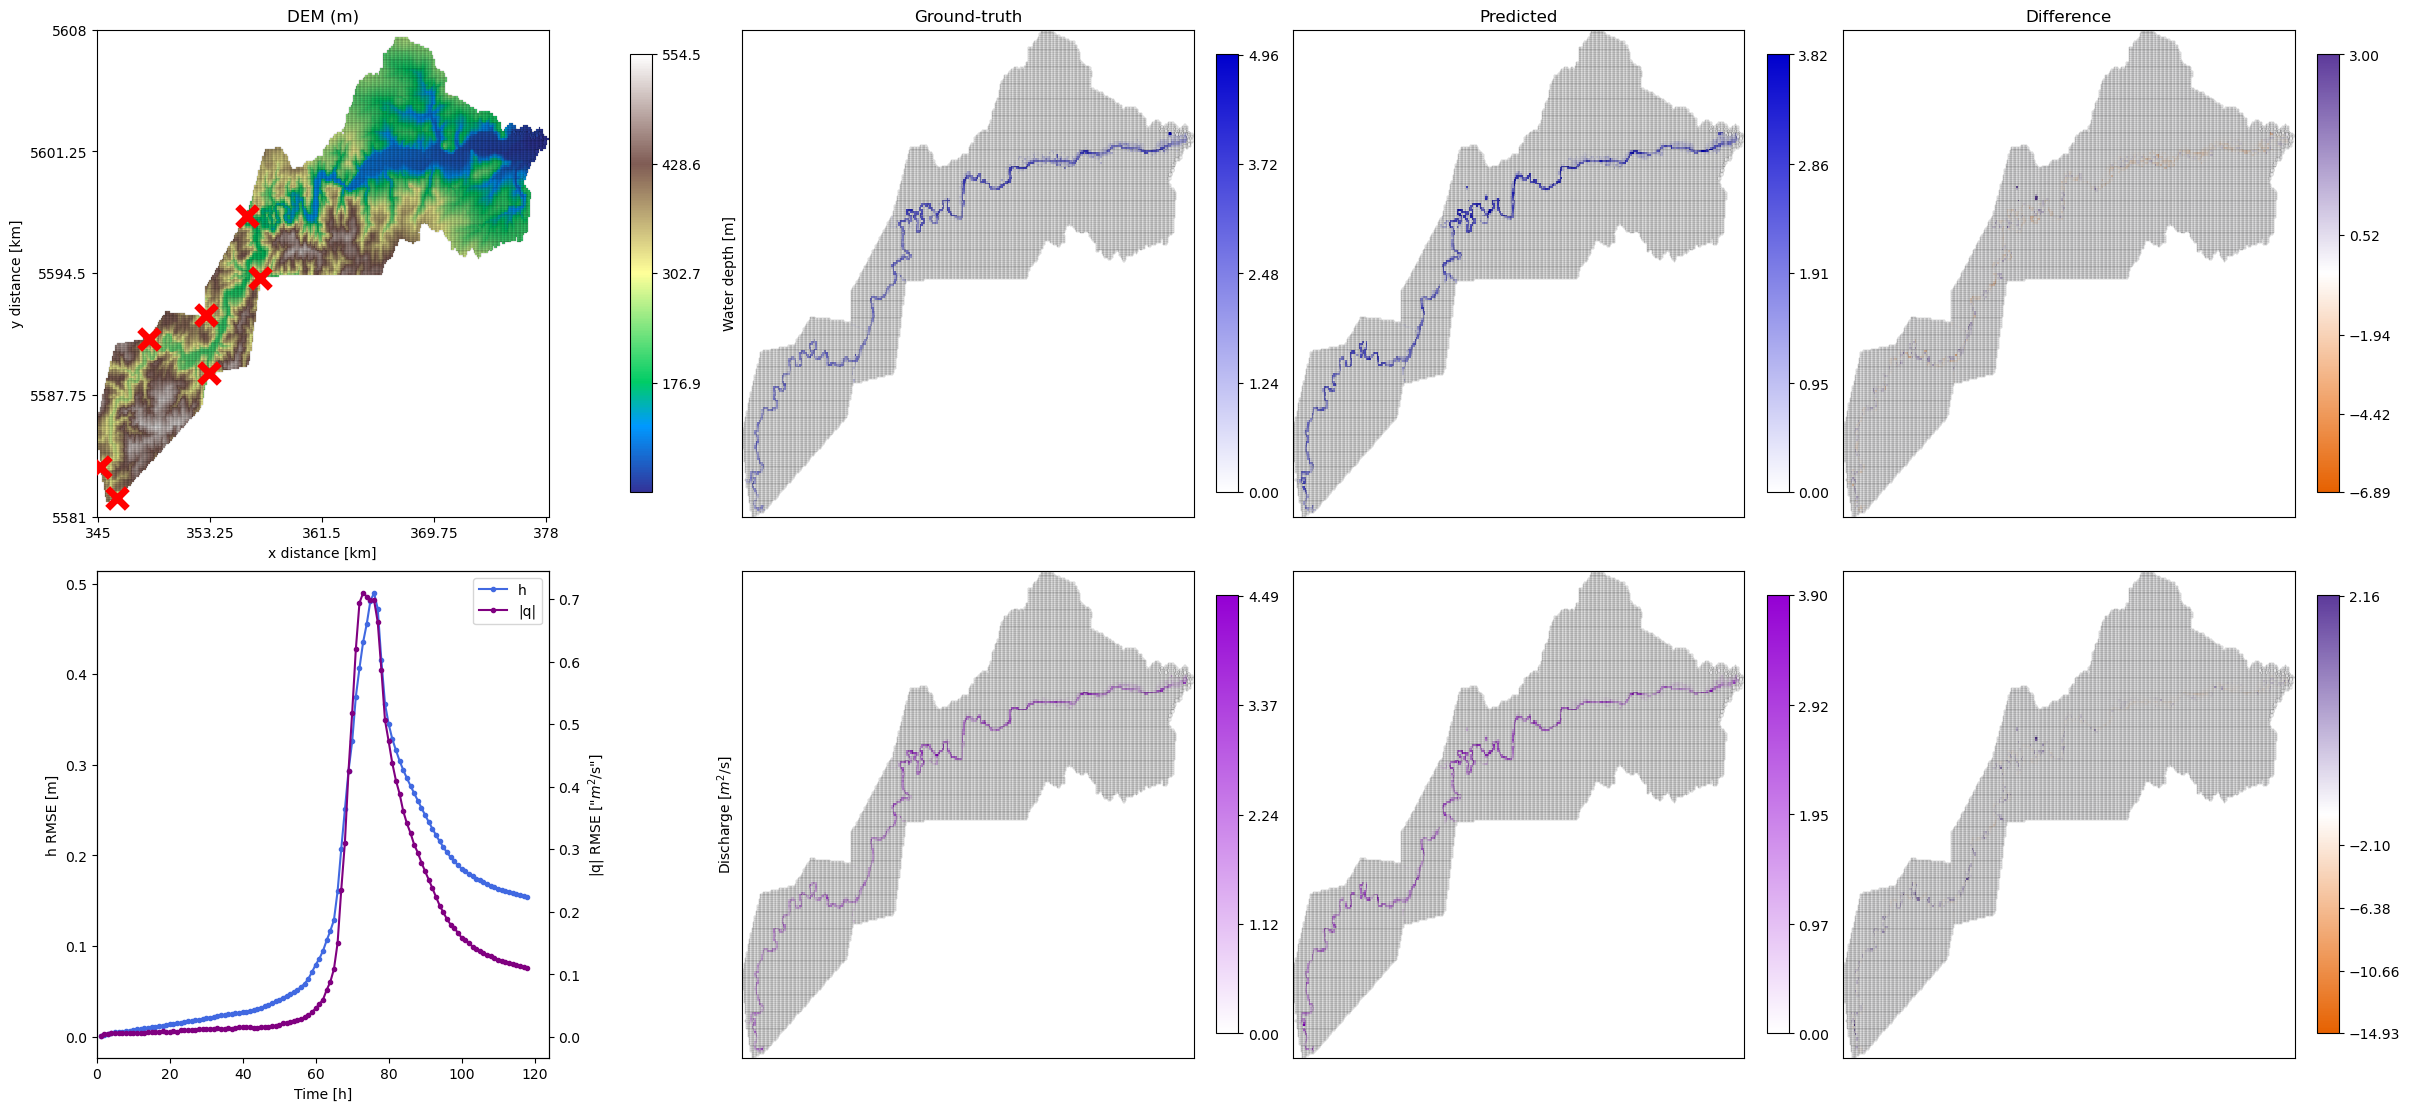

--- multisim_msloss_best_valloss ---


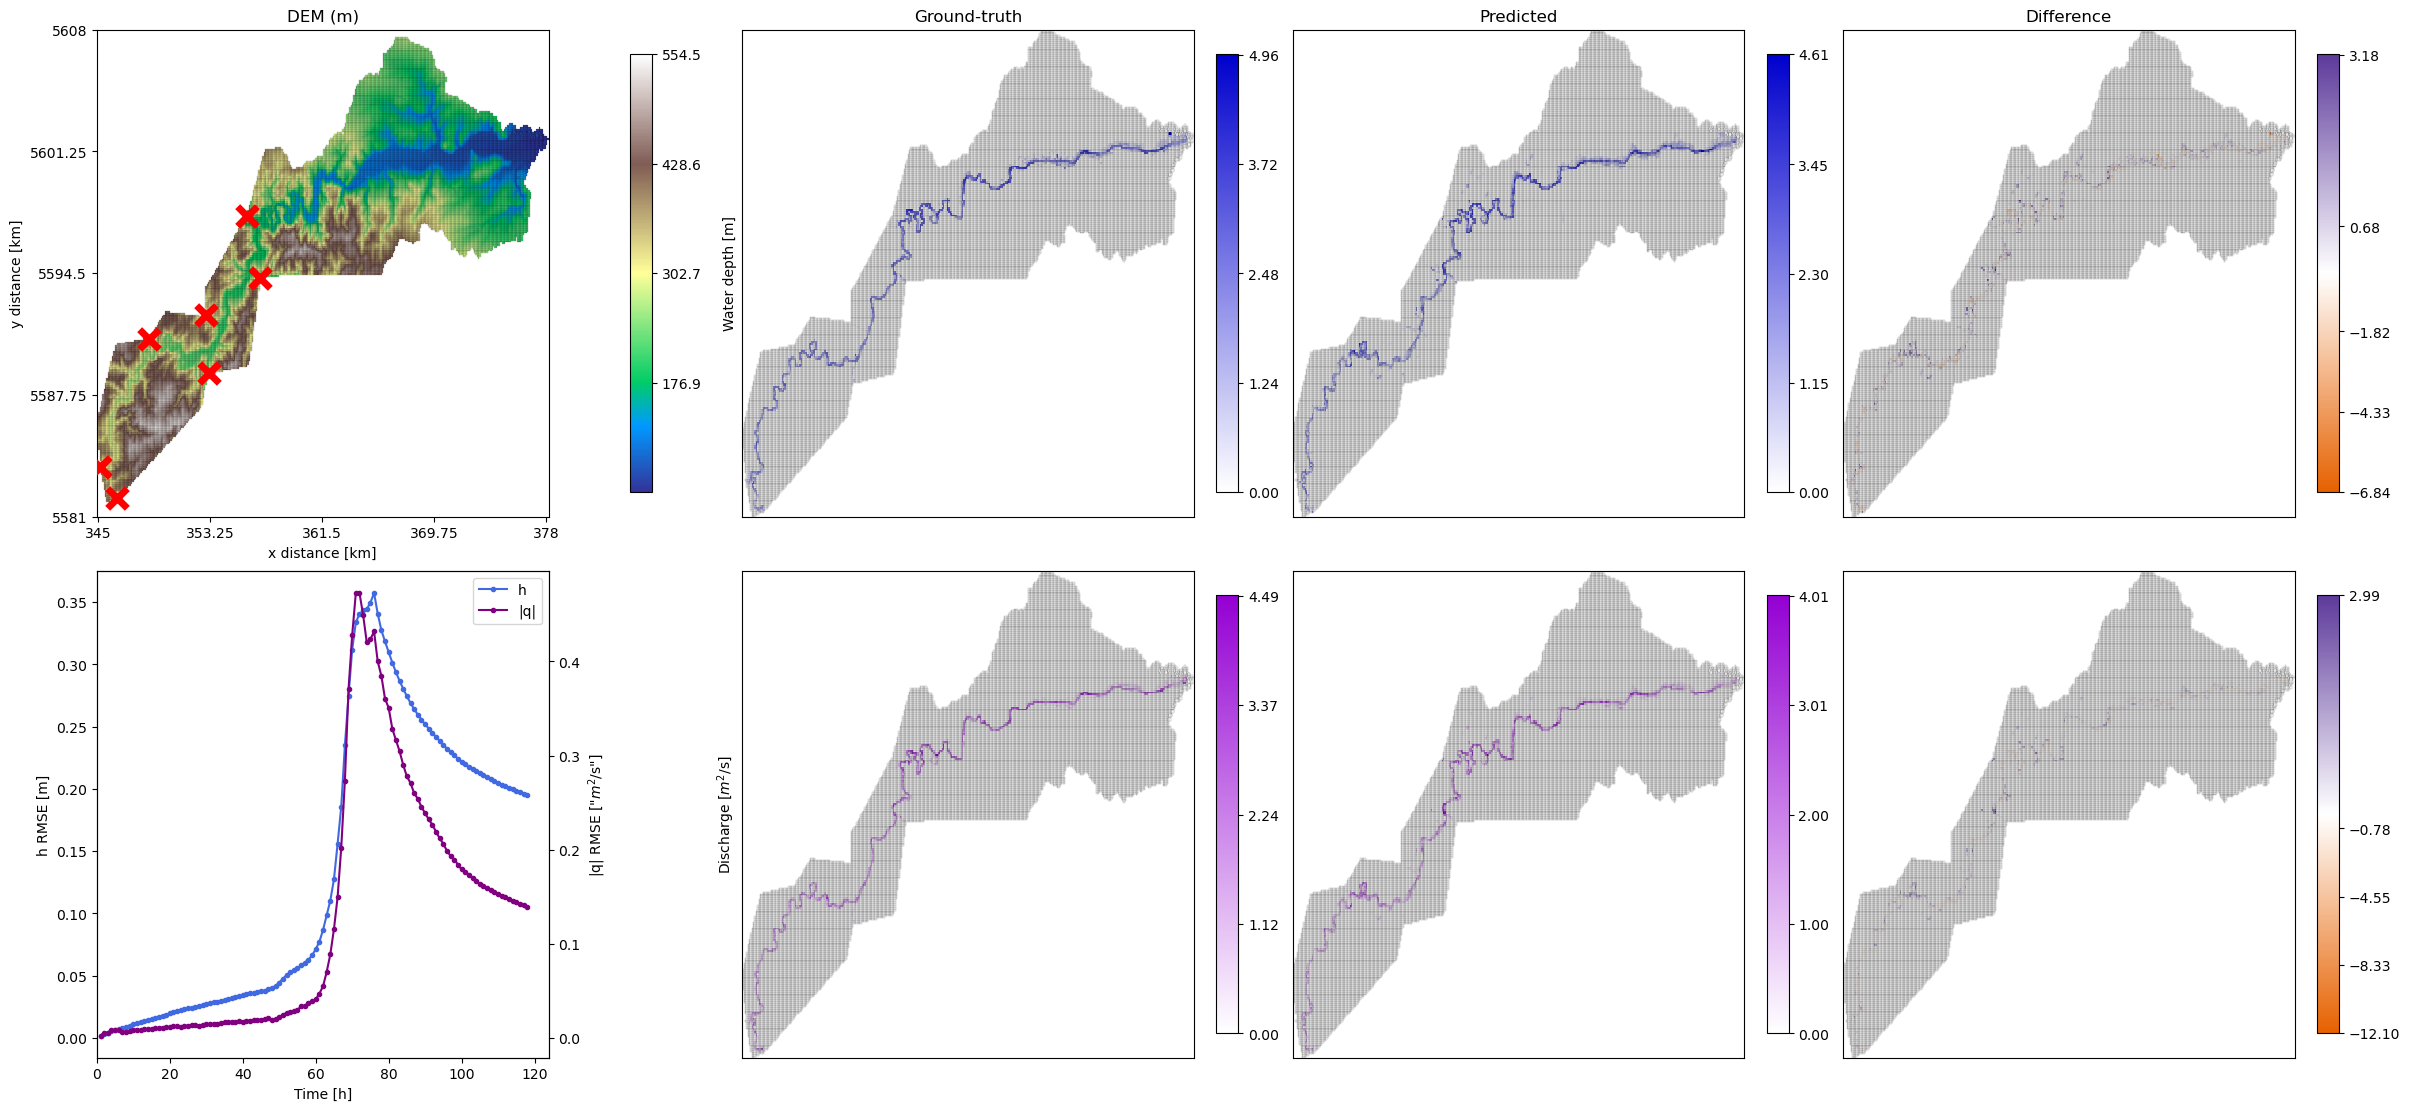

In [14]:
# Final-timestep flood map — all models side by side
for name, r in results.items():
    print(f'--- {name} ---')
    fig = r['plot_rollout'].explore_rollout(scale=0, time_step=-1)
    plt.show()

--- bcaugment_best_valloss ---


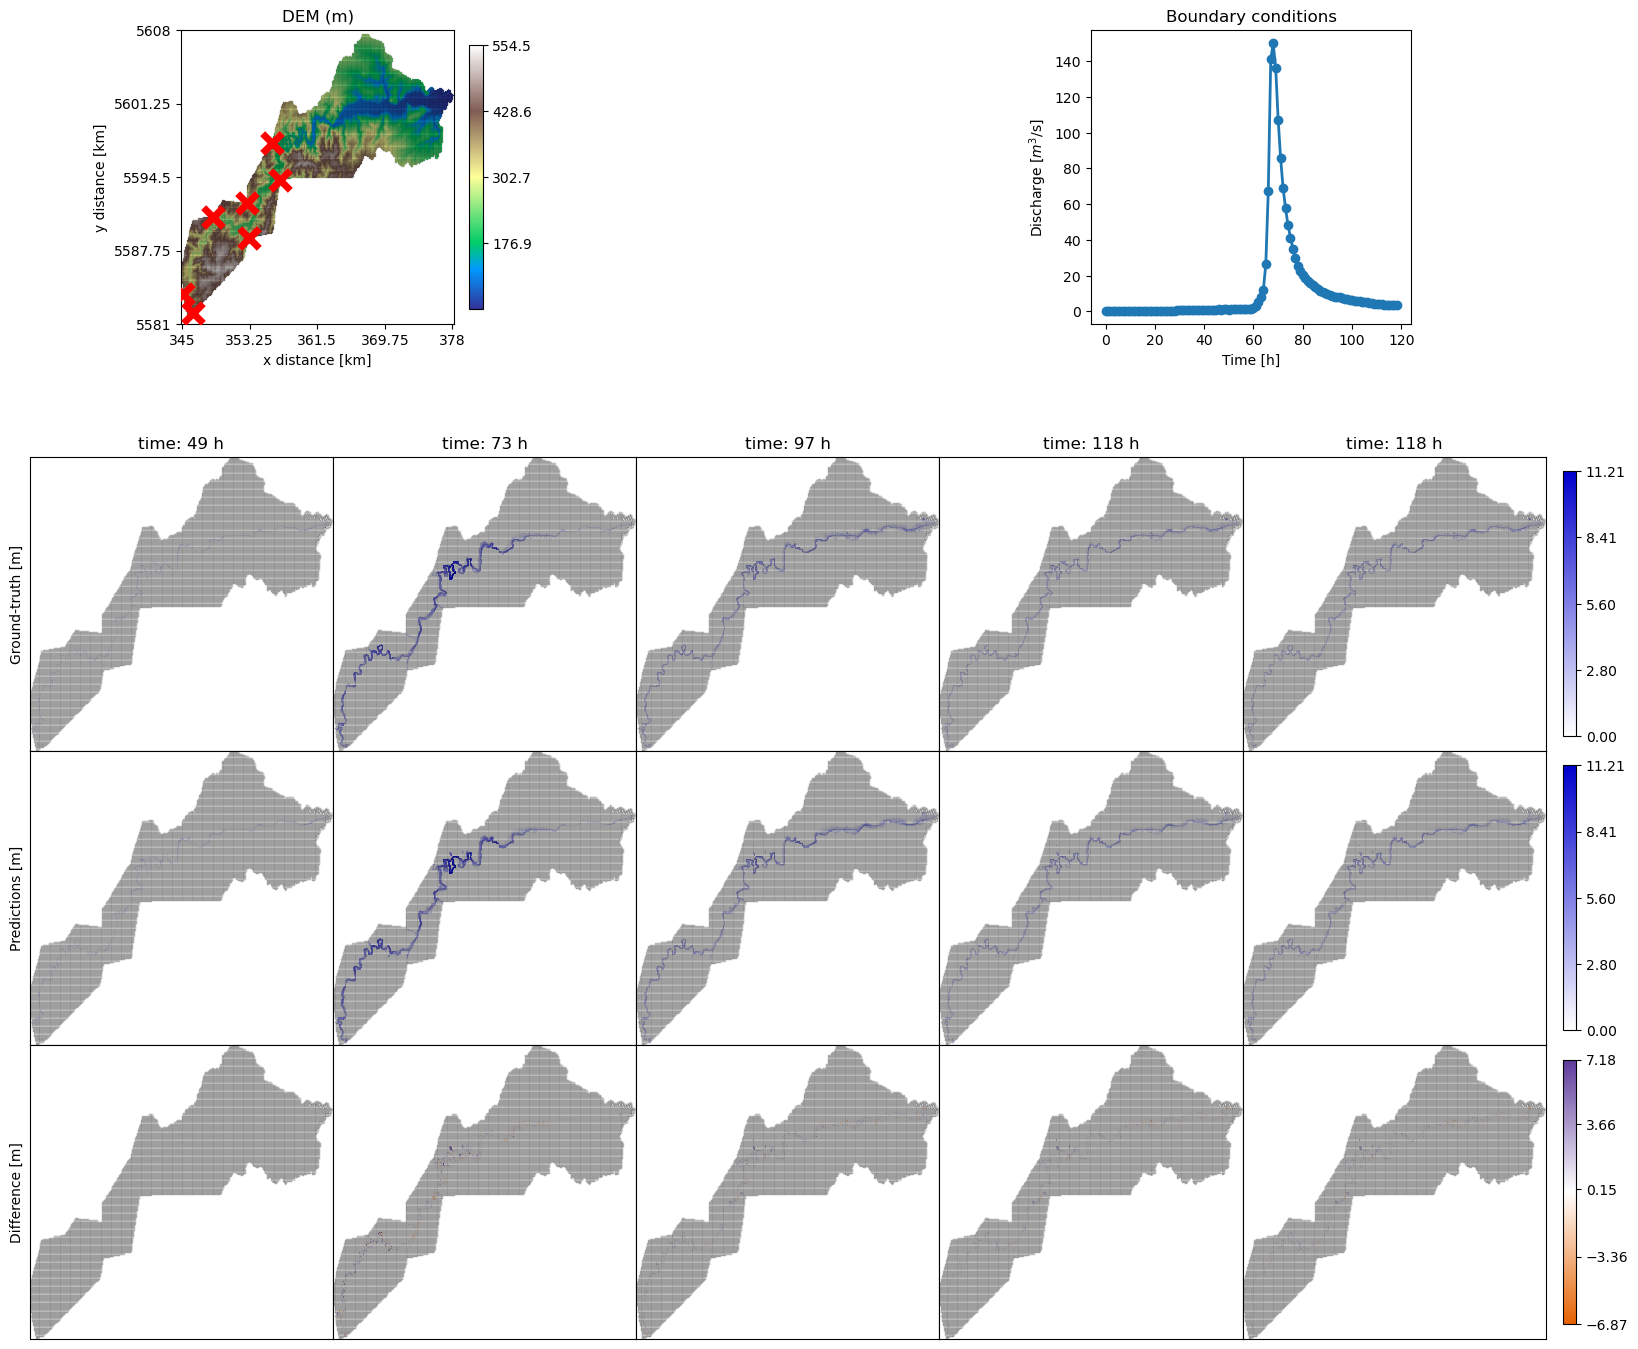

--- bcaugment_bestCSI ---


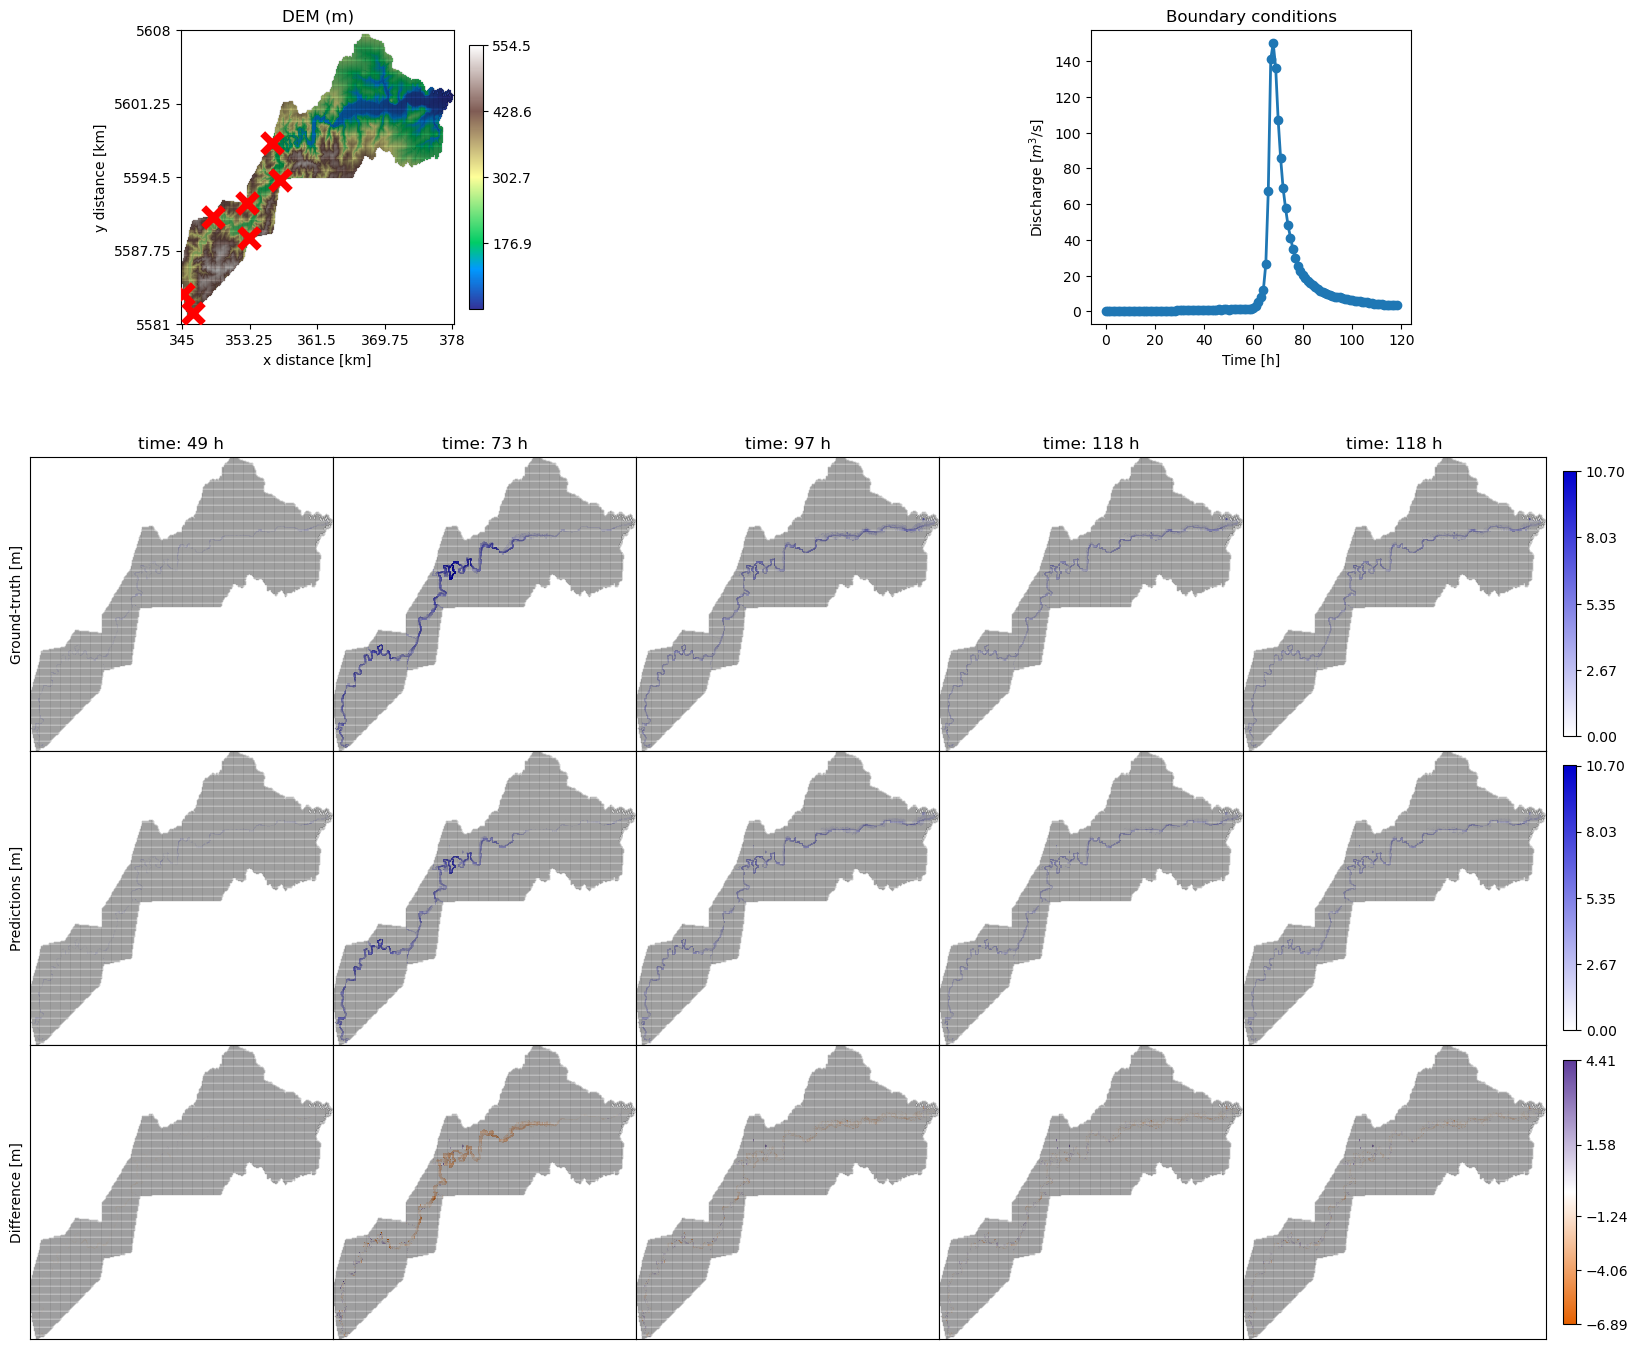

--- multisim_msloss_best_valloss ---


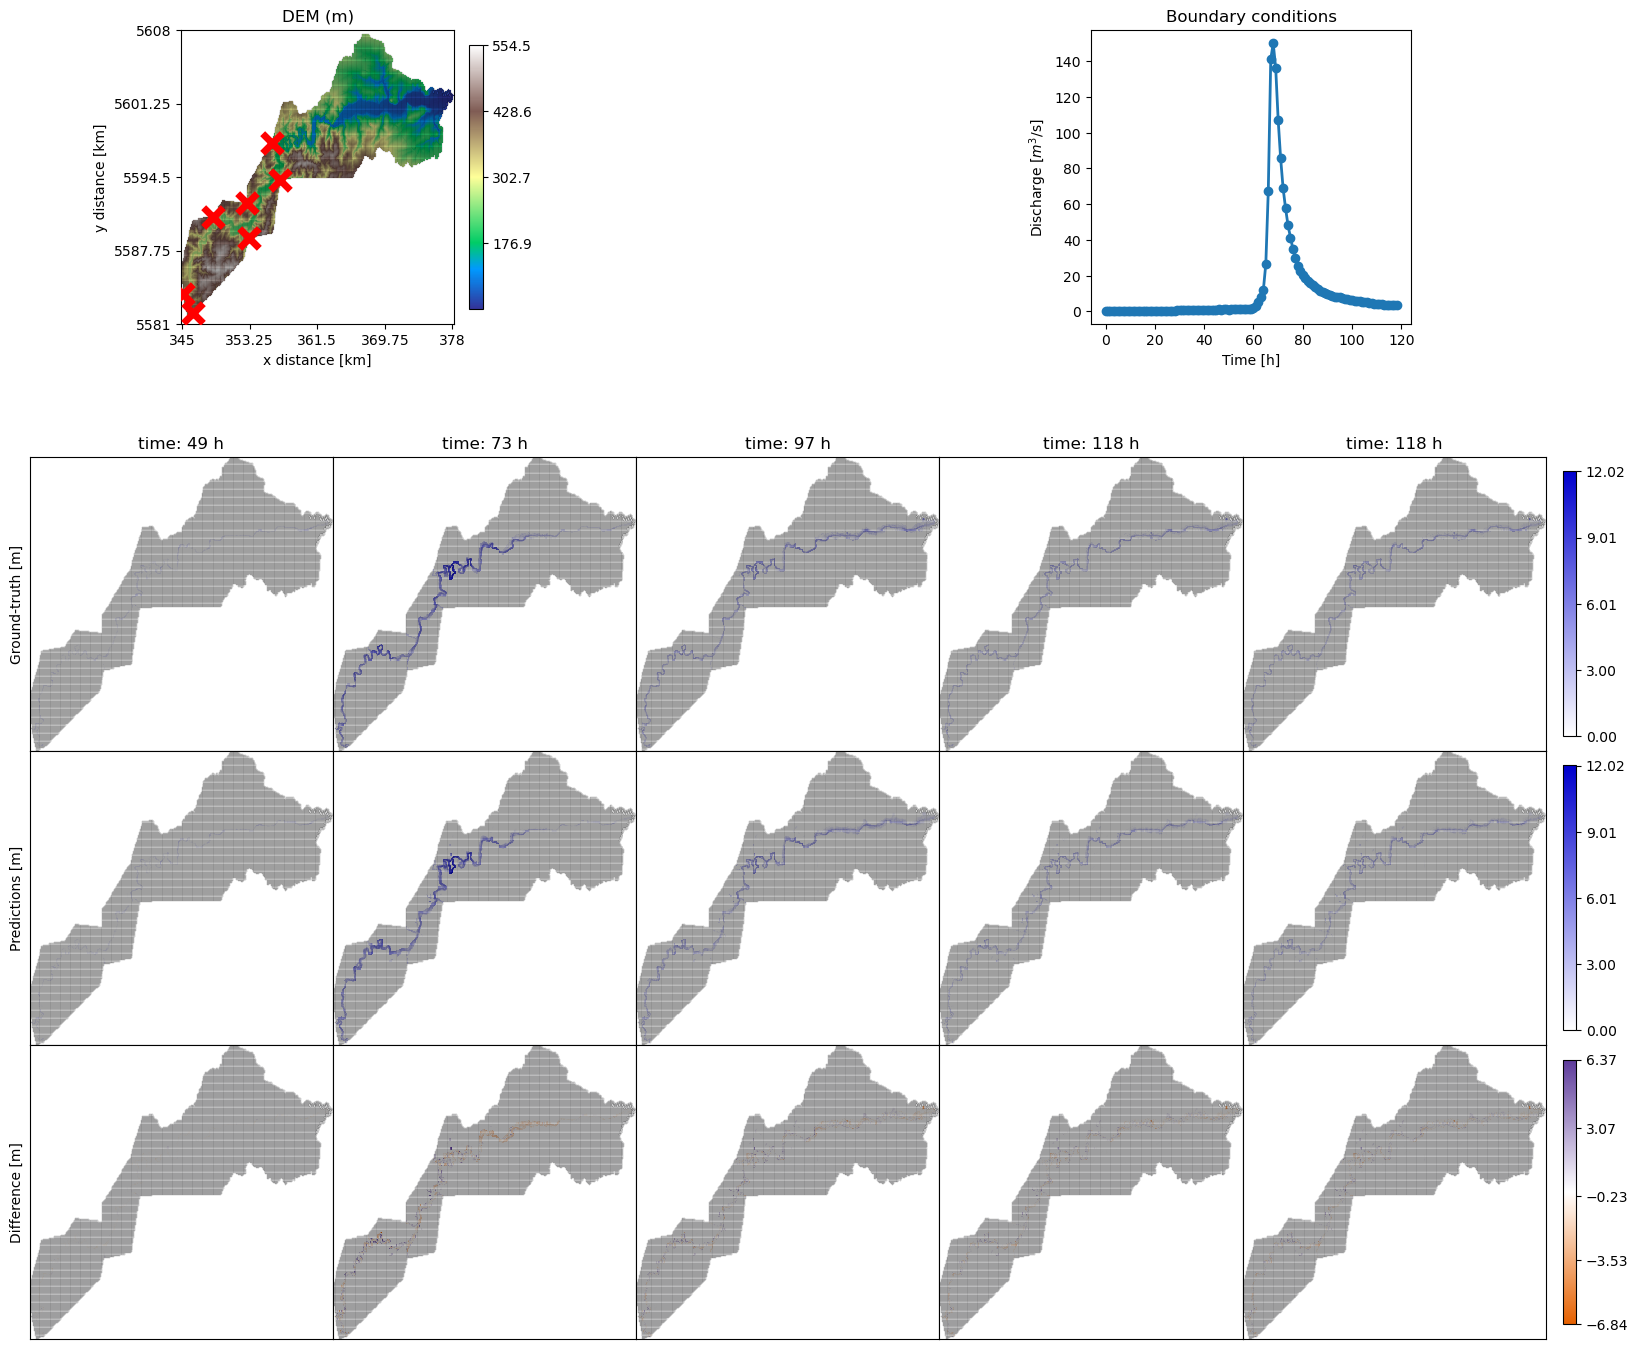

In [ ]:
for name, r in results.items():
    print(f'--- {name} ---')
    n_steps = r['plot_rollout'].real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    r['plot_rollout'].compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()

## Forcing sensitivity (T8) — scale the BC hydrograph, measure the response
A physically meaningful surrogate must respond monotonically to the inflow (bigger hydrograph →
bigger flood). A **flat response = event memorization**: the model cannot be used for what-if scenarios.
Also computes a **persistence baseline** (initial state held for the whole rollout) to contextualize
all CSI numbers on this warm-started event.

BC x 0.00:  CSI@0.05=0.7062   WDsum@peak(t75)=     725   WDsum@end=     801   maxWD=2.93 m
BC x 0.50:  CSI@0.05=0.8560   WDsum@peak(t75)=    5369   WDsum@end=    2369   maxWD=8.35 m
BC x 0.75:  CSI@0.05=0.8581   WDsum@peak(t75)=    6934   WDsum@end=    2776   maxWD=9.93 m
BC x 1.00:  CSI@0.05=0.8527   WDsum@peak(t75)=    8208   WDsum@end=    2966   maxWD=11.21 m
BC x 1.25:  CSI@0.05=0.8328   WDsum@peak(t75)=    8984   WDsum@end=    3289   maxWD=11.99 m
BC x 1.50:  CSI@0.05=0.8195   WDsum@peak(t75)=    9917   WDsum@end=    3531   maxWD=13.19 m
BC x 2.00:  CSI@0.05=0.7910   WDsum@peak(t75)=   10951   WDsum@end=    4149   maxWD=14.34 m

ground truth (1x): WDsum@peak=7767   WDsum@end=2519   maxWD=10.71 m
persistence baseline: CSI@0.05=0.7506  CSI@0.30=0.7201


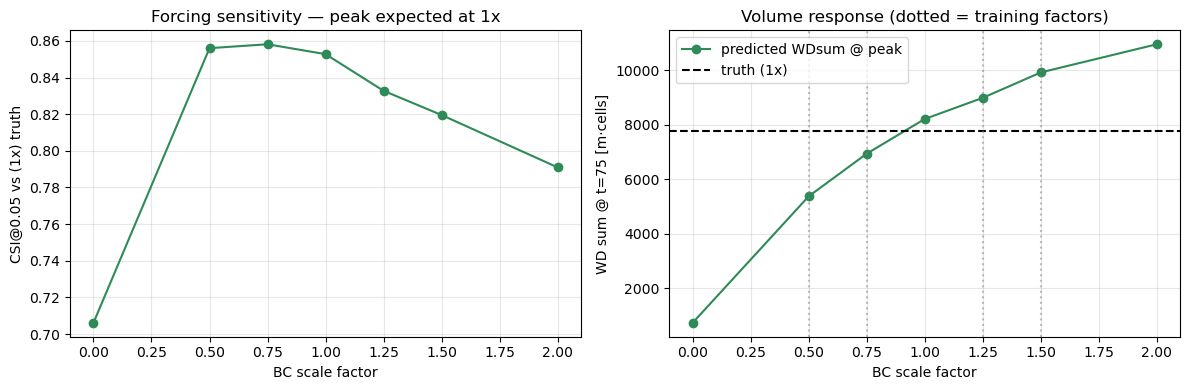

In [16]:
# Uses bcaugment best-val-loss by default — check the epoch/per-scale-volume diagnostic above
# before trusting this; swap to 'bcaugment_bestCSI' if best_valloss turns out to be the
# undertrained checkpoint instead (unlike the old multisim_msloss run, we don't yet know which
# of these two is better converged since training was interrupted, not run to completion).
from training.train import rollout_test_warmstart
from utils.dataset import separate_multiscale_node_features
from utils.miscellaneous import get_CSI

model_sens = results['bcaugment_best_valloss']['plot_rollout'].model
model_sens.eval()

td = temporal_test_dataset[0]
node_ptr = test_dataset[0].node_ptr
gt_s0 = separate_multiscale_node_features(td.y.detach(), node_ptr)[0]
ws_gt = gt_s0[:, 0, :].clamp(min=0).sum(0)
t_pk = int(ws_gt.argmax())

rows = []
for f in [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    tdf = td.clone()
    tdf.BC = td.BC * f
    with torch.no_grad():
        pred = rollout_test_warmstart(model_sens, tdf, warmup_steps=0).detach()
    p_s0 = separate_multiscale_node_features(pred, node_ptr)[0]
    csi = get_CSI(p_s0, gt_s0, water_threshold=0.05).nanmean().item()
    ws = p_s0[:, 0, :].clamp(min=0).sum(0)
    rows.append((f, csi, float(ws[t_pk]), float(ws[-1]), float(p_s0[:, 0, :].max())))
    print(f'BC x {f:4.2f}:  CSI@0.05={csi:.4f}   WDsum@peak(t{t_pk})={ws[t_pk]:8.0f}   WDsum@end={ws[-1]:8.0f}   maxWD={p_s0[:,0,:].max():.2f} m')

print(f'\nground truth (1x): WDsum@peak={ws_gt[t_pk]:.0f}   WDsum@end={ws_gt[-1]:.0f}   maxWD={gt_s0[:,0,:].max():.2f} m')

# Persistence baseline: prediction = state at t=0 for the whole rollout
persist = gt_s0[:, :, 0:1].repeat(1, 1, gt_s0.shape[-1])
print(f'persistence baseline: CSI@0.05={get_CSI(persist, gt_s0, water_threshold=0.05).nanmean().item():.4f}  '
      f'CSI@0.30={get_CSI(persist, gt_s0, water_threshold=0.30).nanmean().item():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fs = [r[0] for r in rows]
ax[0].plot(fs, [r[1] for r in rows], 'o-', color='seagreen')
ax[0].set_xlabel('BC scale factor'); ax[0].set_ylabel('CSI@0.05 vs (1x) truth')
ax[0].set_title('Forcing sensitivity — peak expected at 1x'); ax[0].grid(alpha=0.3)
ax[1].plot(fs, [r[2] for r in rows], 'o-', color='seagreen', label='predicted WDsum @ peak')
ax[1].axhline(float(ws_gt[t_pk]), ls='--', c='k', label='truth (1x)')
for f_train in [0.5, 0.75, 1.25, 1.5]:
    ax[1].axvline(f_train, color='grey', ls=':', alpha=0.5)
ax[1].set_xlabel('BC scale factor'); ax[1].set_ylabel(f'WD sum @ t={t_pk} [m·cells]')
ax[1].set_title('Volume response (dotted = training factors)')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize the 0x forcing scaling inference
*using the bcaugment best-val-loss checkpoint*

The validation dataset you are using is the training one. Careful!
alldrain (in-training-set, catchment emptying from baseline):
  RMSE_WD=0.1263  CSI@0.05=0.3387
  for context, this model on the held-out 1.0x event: RMSE_WD=0.1005  CSI@0.05=0.8527


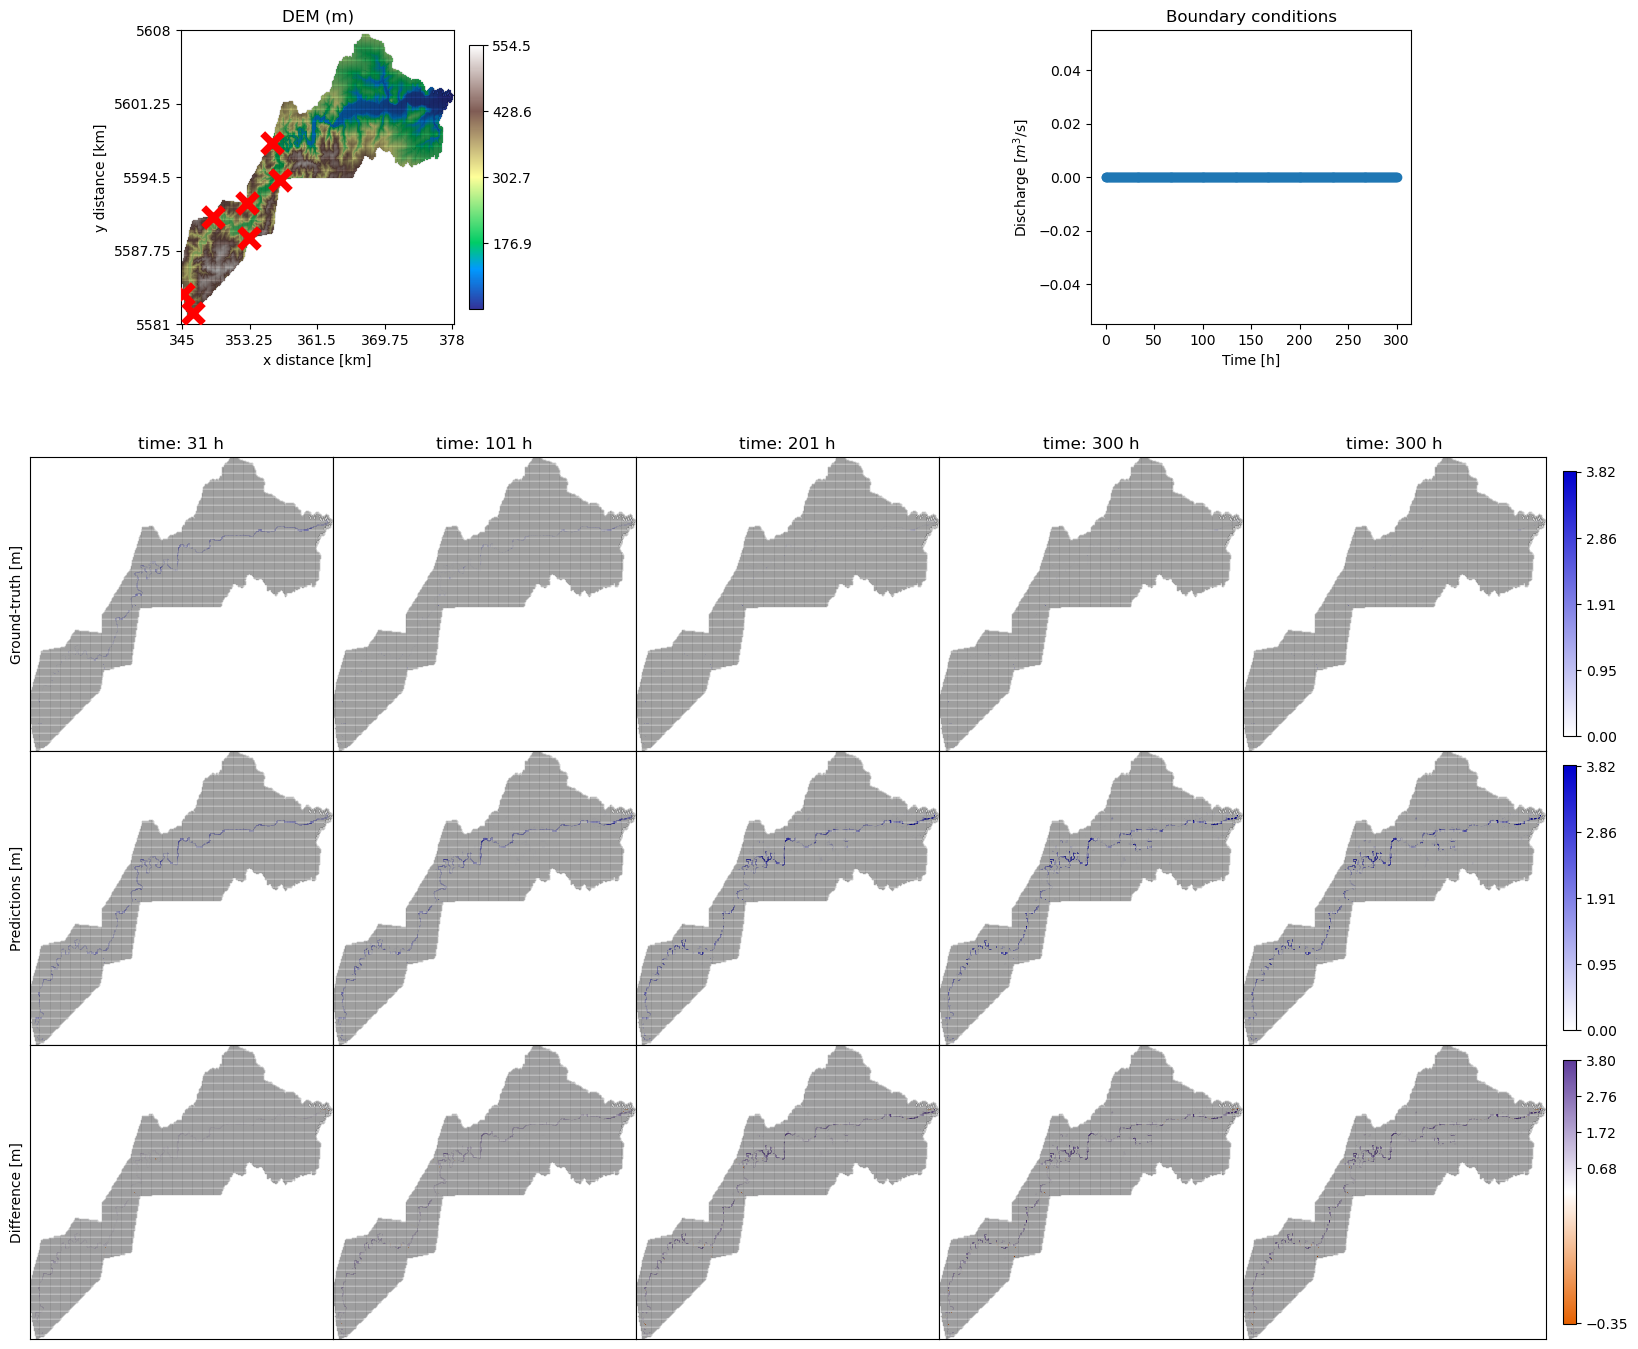

In [22]:
ALLDRAIN_NAME = 'ahr_river_v03_marg_alldrain_additionalsrc_velocity_100m_warmstart'

model = results['bcaugment_best_valloss']['plot_rollout'].model
model.eval()

# alldrain IS one of the 16 BC-augmentation training sims (catchment emptying from the pre-flood
# baseline, all discharge = 0) — unlike the synthetic BC-x0 probe on the held-out 1.0x event above,
# this is real SFINCS ground truth for a scenario the model actually trained on. If training
# worked, this should look close to perfect; if it doesn't, that's a real problem, not just an
# out-of-distribution generalization gap.
cfg_ad = read_config(CONFIG)
cfg_ad['dataset_parameters']['test_dataset_name']  = ALLDRAIN_NAME
cfg_ad['dataset_parameters']['train_dataset_name'] = ALLDRAIN_NAME
wandb.init(mode='disabled', project='mswe-gnn', config=cfg_ad, reinit=True)
fix_dict_in_config(wandb)
config_ad = wandb.config
_, _, test_dataset_ad, scalers_ad = create_model_dataset(
    scalers=config_ad.scalers, device=device,
    **config_ad.dataset_parameters,
    **config_ad.selected_node_features,
    **config_ad.selected_edge_features)
ttdp_ad = get_temporal_test_dataset_parameters(config_ad, config_ad.temporal_dataset_parameters)

pr_alldrain = PlotRollout(model, test_dataset_ad[0], scalers=scalers_ad, warmup_steps=0, **ttdp_ad)

rl = pr_alldrain._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_alldrain = rl[0].item() if rl.ndim > 0 else rl.item()
csi005_alldrain = pr_alldrain._get_CSI(water_threshold=0.05).nanmean().item()
print(f'alldrain (in-training-set, catchment emptying from baseline):')
print(f'  RMSE_WD={rmse_alldrain:.4f}  CSI@0.05={csi005_alldrain:.4f}')
print(f'  for context, this model on the held-out 1.0x event: '
      f"RMSE_WD={results['bcaugment_best_valloss']['rmse_wd']:.4f}  "
      f"CSI@0.05={results['bcaugment_best_valloss']['csi_005']:.4f}")

n_steps_alldrain = pr_alldrain.real_rollout.shape[-1]
plot_times = [n_steps_alldrain // 10, n_steps_alldrain // 3, 2 * n_steps_alldrain // 3, n_steps_alldrain - 1]
pr_alldrain.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()

### Short-horizon check: is this compounding drift, or a wrong learned decay rate?

`alldrain` was in training, but only ever as 5-step window

`alldrain` is also the *only* one of the 20 training events that drains all the way to near-zero

Two possible explanations for the same symptom:
1. **Rollout-length compounding** — correct short-horizon dynamics, wrong long-horizon behavior once
   
2. **Insufficient exposure to this regime** — only one real example of "drains to near-zero" versus
  

alldrain, first 20 steps only:
  RMSE_WD=0.0214  CSI@0.05=0.9247
  for context, same model on the FULL ~300-step alldrain rollout: RMSE_WD=0.1263  CSI@0.05=0.3387


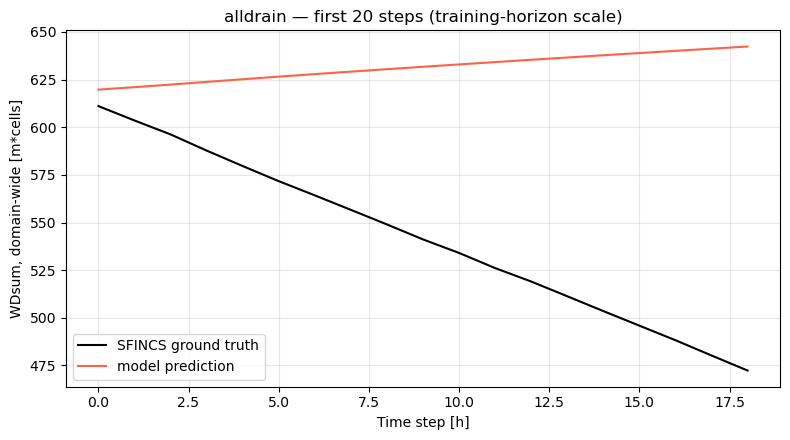

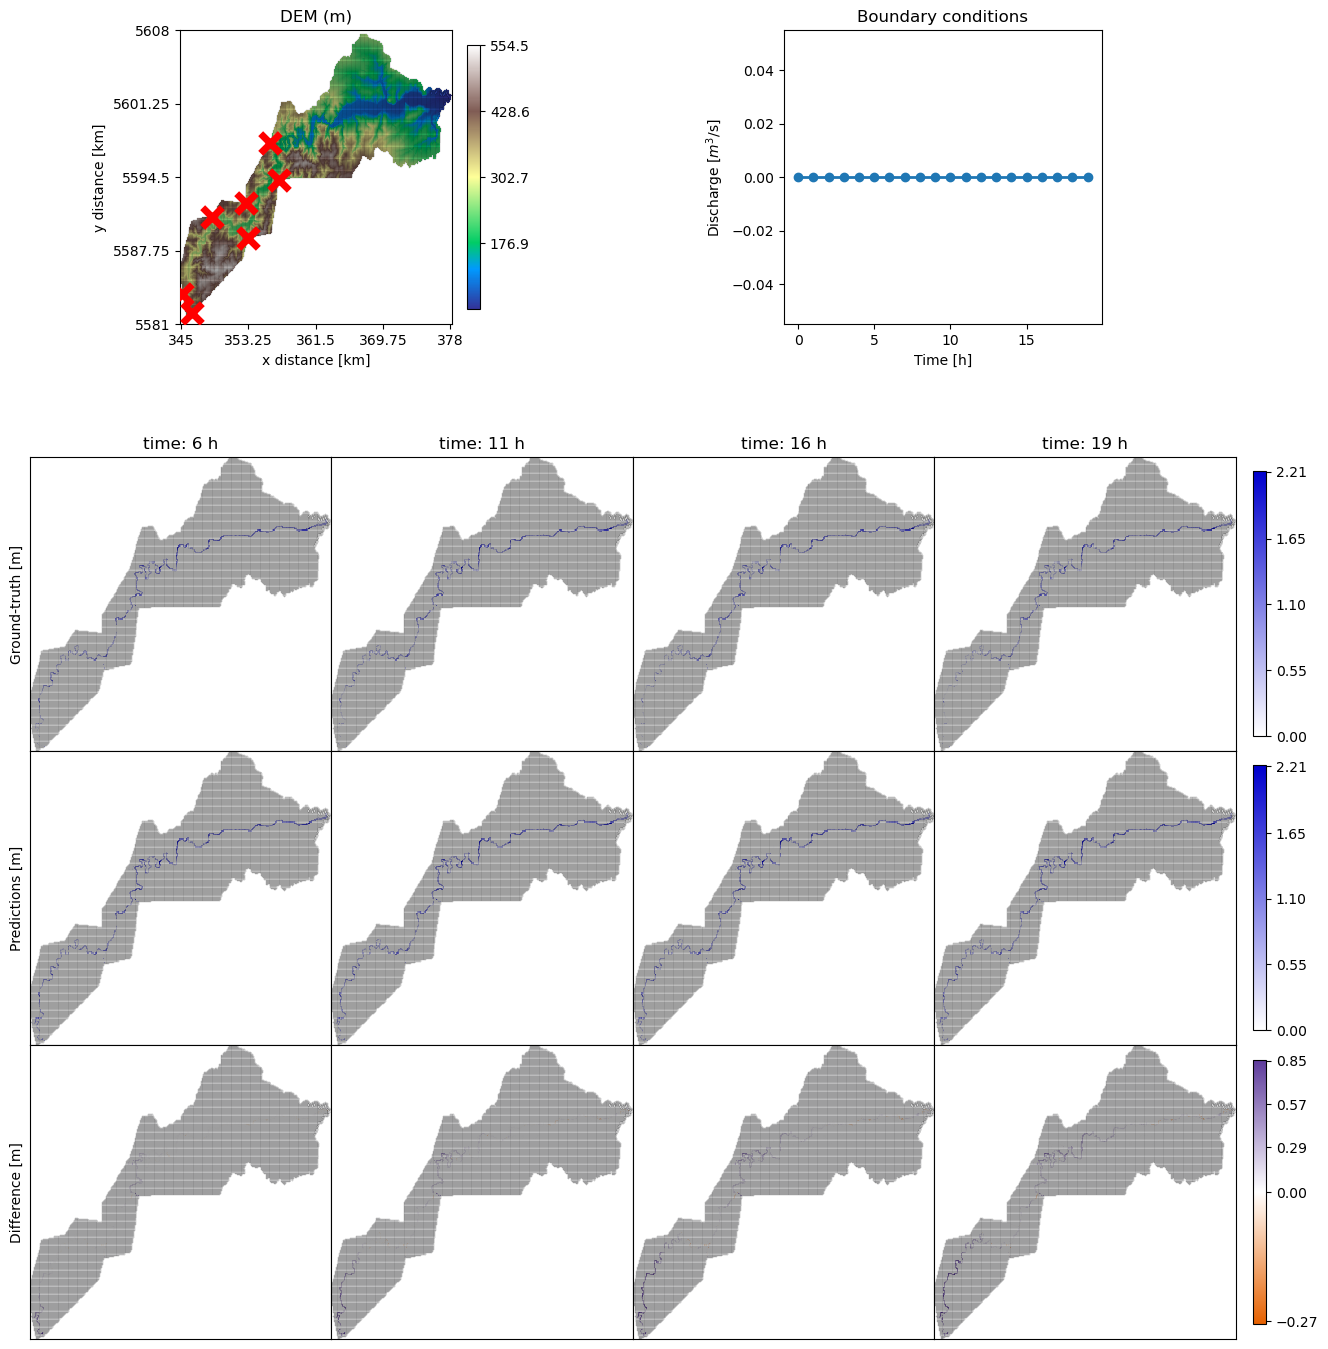

In [20]:
import copy

SHORT_STEPS = 20  # well beyond the training rollout_steps=5, far short of the full ~300-step trajectory

short_data = copy.deepcopy(test_dataset_ad[0])
short_data.WD = short_data.WD[:, :SHORT_STEPS]
short_data.V  = short_data.V[:, :SHORT_STEPS]
short_data.BC = short_data.BC[:, :SHORT_STEPS]  # BC is already 2D [n_bc, T] at this stage, not [n_bc, T, 2]

pr_alldrain_short = PlotRollout(model, short_data, scalers=scalers_ad, warmup_steps=0, **ttdp_ad)

rl_short = pr_alldrain_short._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_short = rl_short[0].item() if rl_short.ndim > 0 else rl_short.item()
csi005_short = pr_alldrain_short._get_CSI(water_threshold=0.05).nanmean().item()
print(f'alldrain, first {SHORT_STEPS} steps only:')
print(f'  RMSE_WD={rmse_short:.4f}  CSI@0.05={csi005_short:.4f}')
print(f'  for context, same model on the FULL ~{n_steps_alldrain}-step alldrain rollout: '
      f'RMSE_WD={rmse_alldrain:.4f}  CSI@0.05={csi005_alldrain:.4f}')

real_ws_short = pr_alldrain_short._real_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()
pred_ws_short = pr_alldrain_short._predicted_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(real_ws_short, label='SFINCS ground truth', color='k')
ax.plot(pred_ws_short, label='model prediction', color='tomato')
ax.set_xlabel('Time step [h]')
ax.set_ylabel('WDsum, domain-wide [m*cells]')
ax.set_title(f'alldrain — first {SHORT_STEPS} steps (training-horizon scale)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# compare_h_rollout appends the final step (-1) automatically, and the rollout here has fewer
# columns than SHORT_STEPS (the first previous_t steps are consumed as model input, not output),
# so don't pass SHORT_STEPS - 1 explicitly — it can be one step past the end.
pr_alldrain_short.compare_h_rollout(plot_times=[5, 10, 15], scale=0)
plt.show()

## Inference at 2x and 3x BC
Extrapolation ladder beyond the training range: 2x = moderate, 3x = aggressive.

Prerequisites: the SFINCS runs `..._cutpolygon_warmstart_q200` / `_q300` (each with its own spinup)
converted onto the template

In [18]:
# Extrapolation evaluation: bcaugment best-val-loss checkpoint on q200/q300
model_ext = results['bcaugment_best_valloss']['plot_rollout'].model
model_ext.eval()

EXTRAP = {'q200': 2.0, 'q300': 3.0}
extrap_pr = {}
extrap_rows = []
for tag, f in EXTRAP.items():
    name = f'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_{tag}'
    if not os.path.exists(f'database/datasets/test/{name}.pkl'):
        print(f'[skip] {tag}: database/datasets/test/{name}.pkl not found (convert it first)')
        continue

    # full pipeline on the extrapolation dataset: correct warm start + correct BC + its own GT
    cfg_f = read_config(CONFIG)
    cfg_f['dataset_parameters']['test_dataset_name']  = name
    cfg_f['dataset_parameters']['train_dataset_name'] = name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg_f, reinit=True)
    fix_dict_in_config(wandb)
    config_f = wandb.config
    _, _, test_f, scalers_f = create_model_dataset(
        scalers=config_f.scalers, device=device,
        **config_f.dataset_parameters,
        **config_f.selected_node_features,
        **config_f.selected_edge_features)

    pr = PlotRollout(model_ext, test_f[0], scalers=scalers_f,
                     warmup_steps=0, **temporal_test_dataset_parameters)
    extrap_pr[tag] = pr

    rl = pr._get_rollout_loss(type_loss='RMSE').mean(0)
    rmse = rl[0].item() if rl.ndim > 0 else rl.item()
    csi005 = pr._get_CSI(water_threshold=0.05).nanmean().item()
    csi03  = pr._get_CSI(water_threshold=0.30).nanmean().item()
    extrap_rows.append((f, rmse, csi005, csi03))
    print(f'BC x {f}:  RMSE_WD={rmse:.4f}  CSI@0.05={csi005:.4f}  CSI@0.30={csi03:.4f}')

if extrap_rows:
    print(f"\ncontext — same model on 1.0x (validation event): "
          f"RMSE_WD={results['bcaugment_best_valloss']['rmse_wd']:.4f}  "
          f"CSI@0.05={results['bcaugment_best_valloss']['csi_005']:.4f}  "
          f"CSI@0.30={results['bcaugment_best_valloss']['csi_03']:.4f}")
    print('generalization ladder: 1.0x = interpolation | 2x = moderate extrapolation | 3x = aggressive extrapolation')

The validation dataset you are using is the training one. Careful!
BC x 2.0:  RMSE_WD=0.1916  CSI@0.05=0.8141  CSI@0.30=0.8897
The validation dataset you are using is the training one. Careful!
BC x 3.0:  RMSE_WD=0.3215  CSI@0.05=0.7900  CSI@0.30=0.8603

context — same model on 1.0x (validation event): RMSE_WD=0.1005  CSI@0.05=0.8527  CSI@0.30=0.8988
generalization ladder: 1.0x = interpolation | 2x = moderate extrapolation | 3x = aggressive extrapolation


--- bcaugment_best_valloss on q200 (vs its own SFINCS ground truth) ---


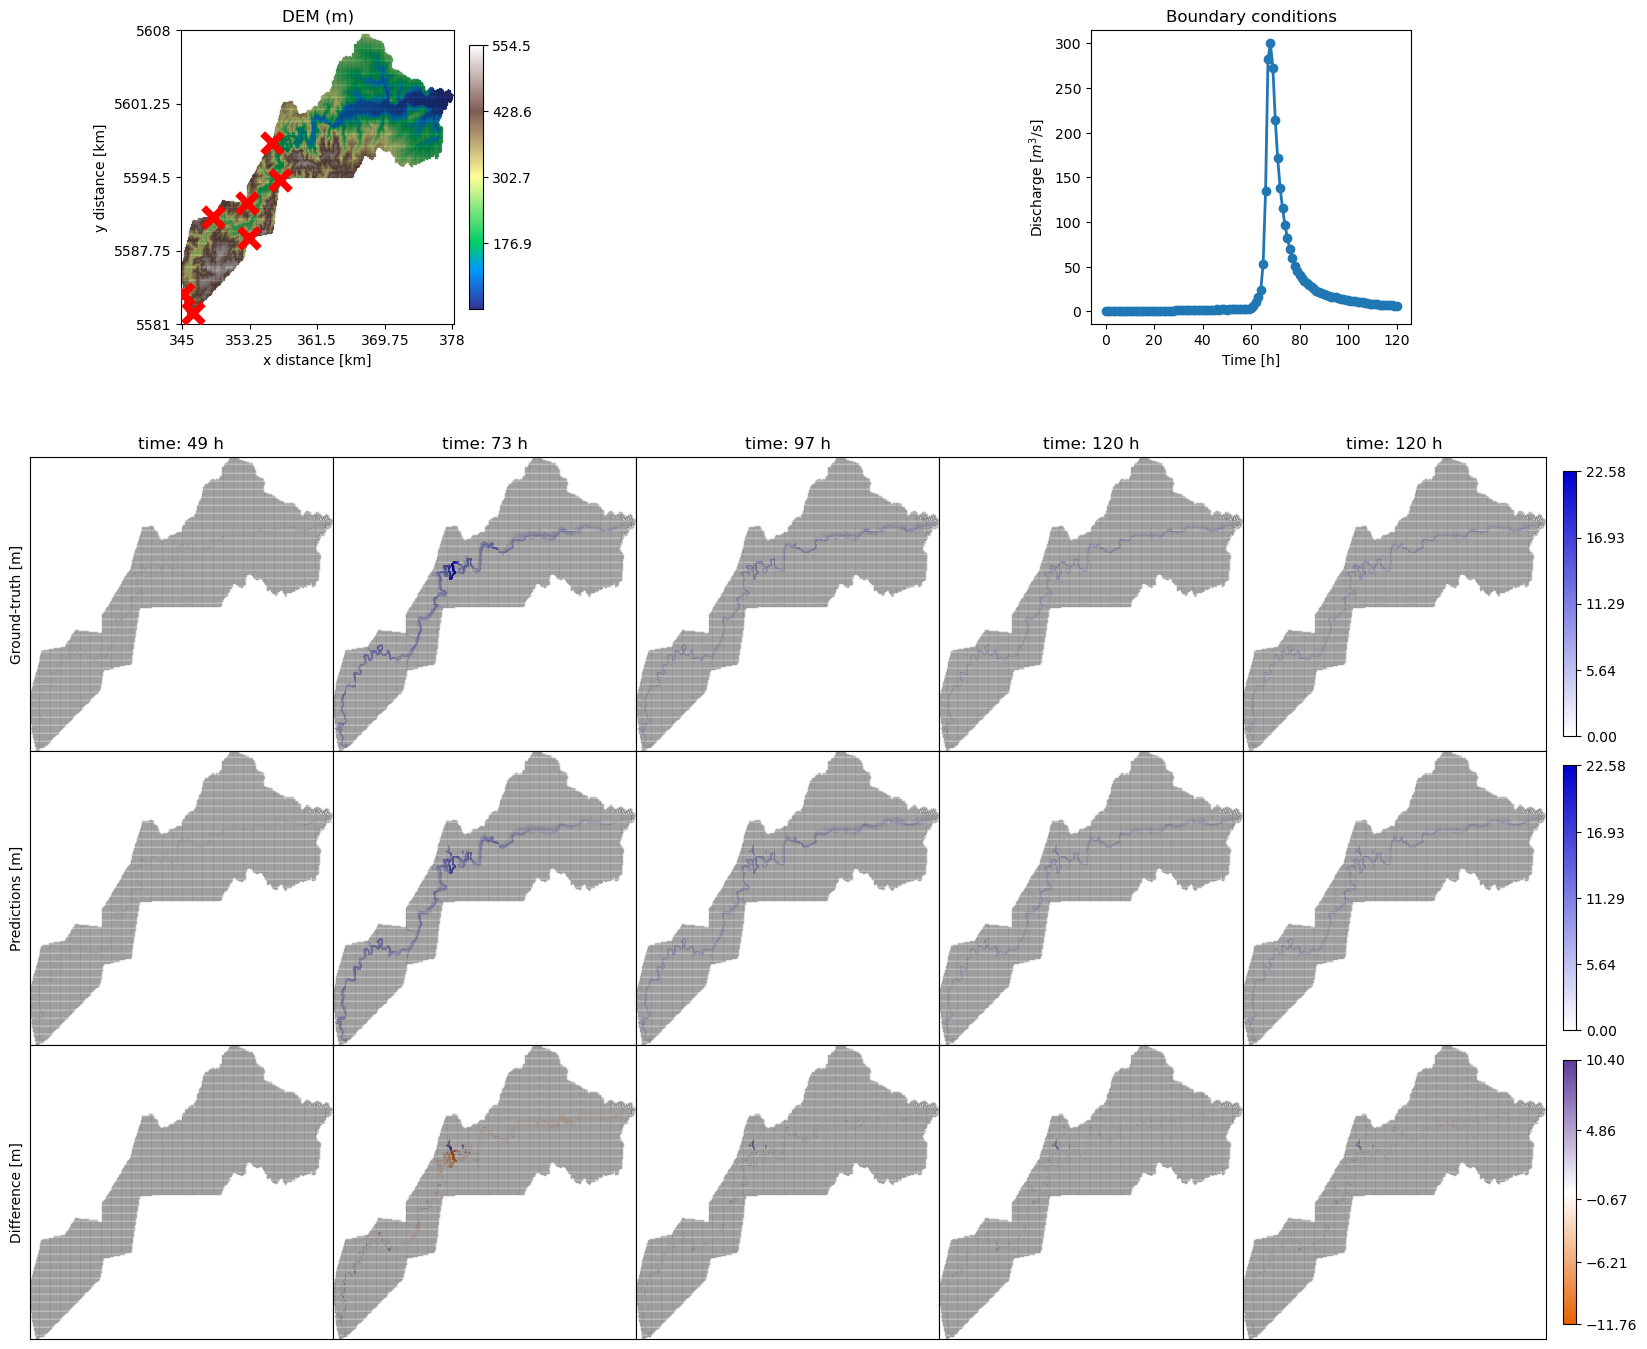

--- bcaugment_best_valloss on q300 (vs its own SFINCS ground truth) ---


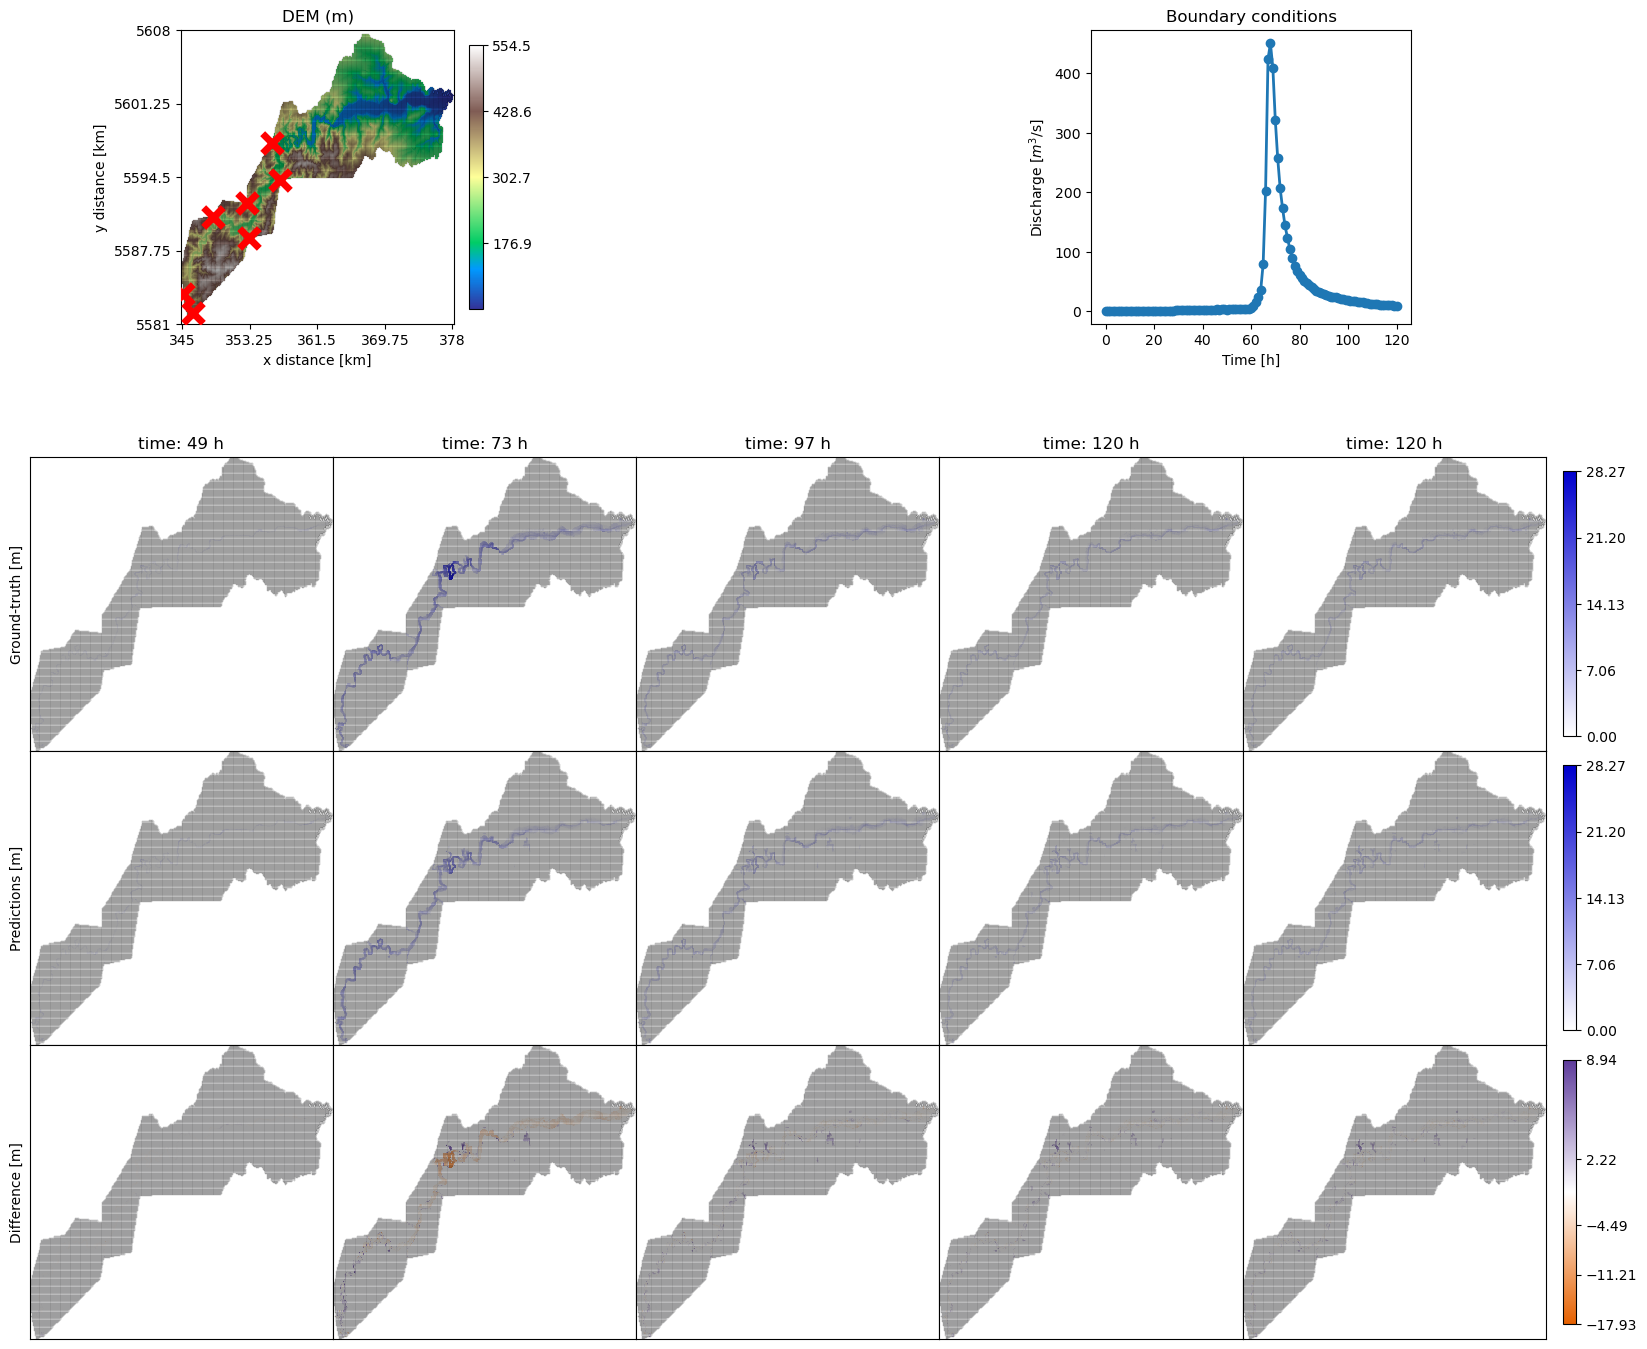

In [19]:
# Maps vs SFINCS ground truth for each extrapolation factor (same style as the 1.0x models above)
for tag, pr in extrap_pr.items():
    print(f'--- bcaugment_best_valloss on {tag} (vs its own SFINCS ground truth) ---')
    n_steps = pr.real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    pr.compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()